# Learning Day 3 — Imbalanced Data

## Credit Card Fraud Detection with Machine Learning

### Project Objective

The goal of this notebook is to understand and solve a real-world **imbalanced classification problem** using the Credit Card Fraud Detection dataset.

In fraud detection, fraudulent transactions are extremely rare compared to normal transactions. Because of this imbalance, a machine learning model can achieve very high accuracy while still failing to detect the minority class — the fraud cases.

This notebook focuses on identifying that problem, applying suitable imbalance-handling techniques, and evaluating models using metrics that are more meaningful than accuracy alone.

---

### What This Notebook Covers

In this project, we will work through the complete Day 3 exercise path:

1. Analyse the class distribution of the target variable.
2. Visualise the imbalance between normal and fraudulent transactions.
3. Explain why accuracy can be misleading in imbalanced datasets.
4. Apply oversampling and undersampling methods.
5. Train and compare Random Forest models on different resampled datasets.
6. Evaluate models using Accuracy, Precision, Recall, F1-Score, ROC-AUC, and ROC curves.
7. Apply cost-sensitive learning using class weights.
8. Optimise the decision threshold to improve minority-class detection.
9. Combine SMOTE with XGBoost and `scale_pos_weight`.
10. Compare all approaches and decide which model is most suitable for real-time fraud detection.

---

### Business Context

In a real fraud detection system, the most important goal is not simply to classify the majority of transactions correctly. The real goal is to detect as many fraudulent transactions as possible while keeping false alarms at an acceptable level.

A missed fraud case can lead to financial loss, while a wrongly flagged normal transaction can negatively affect customer experience. Therefore, this project focuses on finding a practical balance between fraud detection performance and business usability.

---

### Key Learning Focus

By the end of this notebook, we should be able to explain:

* Why imbalanced data is a serious problem in machine learning.
* Why accuracy alone is not enough for fraud detection.
* How Precision, Recall, F1-Score, and ROC-AUC help evaluate minority-class performance.
* How oversampling, undersampling, SMOTE, Tomek Links, and class weights work.
* Why threshold optimisation is important in real-world classification.
* How to compare models from both technical and business perspectives.


In [1]:
#%pip uninstall -y kagglehub kagglesdk kaggle
#%pip install -q --upgrade --force-reinstall --no-cache-dir kagglehub kagglesdk

In [2]:
# ------------------------------------------------------------
# Core libraries
# ------------------------------------------------------------

import os
import glob
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns


# ------------------------------------------------------------
# Notebook display settings
# ------------------------------------------------------------

# Show all columns when displaying DataFrames
pd.set_option("display.max_columns", None)

# Show floating-point numbers with 4 decimal places
pd.set_option("display.float_format", "{:.4f}".format)


# ------------------------------------------------------------
# Plot styling
# ------------------------------------------------------------

# Use a clean professional chart style
sns.set_theme(style="whitegrid", context="notebook")


# ------------------------------------------------------------
# Global random seed for reproducibility
# ------------------------------------------------------------

RANDOM_STATE = 42

In [3]:
# ------------------------------------------------------------
# Dataset configuration
# ------------------------------------------------------------

# Kaggle dataset name
DATASET_NAME = "mlg-ulb/creditcardfraud"

# Local fallback file.
# This assumes creditcard.csv is saved in the same folder as this notebook.
LOCAL_CSV_PATH = Path("creditcard.csv")


# ------------------------------------------------------------
# Load dataset
# ------------------------------------------------------------

df = None
data_source = None

try:
    # Try to import KaggleHub only inside this block.
    # This prevents the whole notebook from failing if KaggleHub has dependency issues.
    import kagglehub

    # Download the dataset from KaggleHub
    path = kagglehub.dataset_download(DATASET_NAME)

    # Search for CSV files inside the downloaded dataset folder
    csv_files = glob.glob(os.path.join(path, "*.csv"))

    # Raise an error if no CSV file is found
    if len(csv_files) == 0:
        raise FileNotFoundError("No CSV file found in the KaggleHub download folder.")

    # Load the first CSV file found
    df = pd.read_csv(csv_files[0])

    # Save source information for documentation
    data_source = f"KaggleHub download: {csv_files[0]}"

except Exception as e:
    # If KaggleHub fails, print the reason and try local CSV instead
    print("KaggleHub download failed.")
    print("Reason:", e)
    print("Trying local CSV fallback...")

    # Check whether local CSV exists
    if LOCAL_CSV_PATH.exists():
        df = pd.read_csv(LOCAL_CSV_PATH)
        data_source = f"Local CSV file: {LOCAL_CSV_PATH}"
    else:
        raise FileNotFoundError(
            "Dataset could not be loaded from KaggleHub or local creditcard.csv. "
            "Please place creditcard.csv in the same folder as this notebook."
        )


# ------------------------------------------------------------
# Confirm successful loading
# ------------------------------------------------------------

print("Dataset loaded successfully.")
print("Data source:", data_source)
print("Dataset shape:", df.shape)

display(df.head())

KaggleHub download failed.
Reason: cannot import name 'get_web_endpoint' from 'kagglesdk.kaggle_env' (/opt/miniconda3/lib/python3.12/site-packages/kagglesdk/kaggle_env.py)
Trying local CSV fallback...
Dataset loaded successfully.
Data source: Local CSV file: creditcard.csv
Dataset shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0000,-1.3598,-0.0728,2.5363,1.3782,-0.3383,0.4624,0.2396,0.0987,0.3638,0.0908,-0.5516,-0.6178,-0.9914,-0.3112,1.4682,-0.4704,0.2080,0.0258,0.4040,0.2514,-0.0183,0.2778,-0.1105,0.0669,0.1285,-0.1891,0.1336,-0.0211,149.6200,0
1,0.0000,1.1919,0.2662,0.1665,0.4482,0.0600,-0.0824,-0.0788,0.0851,-0.2554,-0.1670,1.6127,1.0652,0.4891,-0.1438,0.6356,0.4639,-0.1148,-0.1834,-0.1458,-0.0691,-0.2258,-0.6387,0.1013,-0.3398,0.1672,0.1259,-0.0090,0.0147,2.6900,0
2,1.0000,-1.3584,-1.3402,1.7732,0.3798,-0.5032,1.8005,0.7915,0.2477,-1.5147,0.2076,0.6245,0.0661,0.7173,-0.1659,2.3459,-2.8901,1.1100,-0.1214,-2.2619,0.5250,0.2480,0.7717,0.9094,-0.6893,-0.3276,-0.1391,-0.0554,-0.0598,378.6600,0
3,1.0000,-0.9663,-0.1852,1.7930,-0.8633,-0.0103,1.2472,0.2376,0.3774,-1.3870,-0.0550,-0.2265,0.1782,0.5078,-0.2879,-0.6314,-1.0596,-0.6841,1.9658,-1.2326,-0.2080,-0.1083,0.0053,-0.1903,-1.1756,0.6474,-0.2219,0.0627,0.0615,123.5000,0
4,2.0000,-1.1582,0.8777,1.5487,0.4030,-0.4072,0.0959,0.5929,-0.2705,0.8177,0.7531,-0.8228,0.5382,1.3459,-1.1197,0.1751,-0.4514,-0.2370,-0.0382,0.8035,0.4085,-0.0094,0.7983,-0.1375,0.1413,-0.2060,0.5023,0.2194,0.2152,69.9900,0


## 2. Initial Dataset Inspection

Before applying any machine learning technique, we first inspect the structure of the dataset.

In this step, we check:

- the number of rows and columns,
- the column names,
- missing values,
- duplicate rows,
- and the distribution of the target variable `Class`.

This is important because imbalanced learning starts with understanding how severe the class imbalance is.

In [4]:
# ------------------------------------------------------------
# Basic dataset inspection
# ------------------------------------------------------------

# Display the number of rows and columns
print("Dataset shape:")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")

print("\n" + "-" * 60)

# Display column names
print("Column names:")
print(df.columns.tolist())

print("\n" + "-" * 60)

# Display basic information about data types and non-null values
print("Dataset information:")
df.info()

print("\n" + "-" * 60)

# Check missing values in each column
missing_values = df.isnull().sum().sort_values(ascending=False)

print("Missing values:")
display(missing_values[missing_values > 0])

# If there are no missing values, show a clear message
if missing_values.sum() == 0:
    print("No missing values found in the dataset.")

print("\n" + "-" * 60)

# Check duplicate rows
duplicate_count = df.duplicated().sum()

print("Duplicate rows:")
print(f"{duplicate_count:,}")

Dataset shape:
Rows: 284,807
Columns: 31

------------------------------------------------------------
Column names:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

------------------------------------------------------------
Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null 

Series([], dtype: int64)

No missing values found in the dataset.

------------------------------------------------------------
Duplicate rows:
1,081


## 3. Target Class Distribution

The target variable in this dataset is `Class`.

- `Class = 0` represents a normal transaction.
- `Class = 1` represents a fraudulent transaction.

Before building any machine learning model, we need to understand how strongly the target variable is imbalanced. 

This step is important because a highly imbalanced target can make accuracy misleading.

What we learned:

Dataset loaded correctly: 
- 284,807 rows and 31 columns
- All features are numeric: Time, V1–V28, Amount, Class
- No missing values
- Target column is Class
- There are 1,081 duplicate rows

In [5]:
# ------------------------------------------------------------
# Target class distribution
# ------------------------------------------------------------

# Count how many transactions belong to each class
class_counts = df["Class"].value_counts().sort_index()

# Calculate the percentage share of each class
class_percentages = df["Class"].value_counts(normalize=True).sort_index() * 100

# Create a clean summary table for reporting
class_distribution = pd.DataFrame({
    "Class": class_counts.index,
    "Meaning": ["Normal Transaction", "Fraud Transaction"],
    "Count": class_counts.values,
    "Percentage": class_percentages.values
})

# Format count with comma separators and percentage with 4 decimal places
class_distribution_display = class_distribution.copy()
class_distribution_display["Count"] = class_distribution_display["Count"].map("{:,}".format)
class_distribution_display["Percentage"] = class_distribution_display["Percentage"].map("{:.4f}%".format)

# Display final class distribution table
display(class_distribution_display)

,Class,Meaning,Count,Percentage
0,0,Normal Transaction,"284,315",99.8273%
1,1,Fraud Transaction,492,0.1727%


### Interpretation

The dataset is extremely imbalanced. Normal transactions represent almost the entire dataset, while fraudulent transactions make up only a very small percentage.

This means that accuracy alone is not reliable. A model could predict nearly all transactions as normal and still achieve very high accuracy, while failing to detect fraud cases.

For this reason, we will later evaluate models using more suitable metrics such as Precision, Recall, F1-Score, ROC-AUC, and confusion matrices.

- Normal transactions: 284,315 → 99.8273%
- Fraud transactions:      492 → 0.1727%

So for every fraud transaction, there are roughly:

284,315 / 492 ≈ 578 normal transactions

## 4. Why Accuracy Is Misleading in Imbalanced Data

The class distribution shows that fraudulent transactions are extremely rare.

If a model simply predicts every transaction as normal, it will still achieve very high accuracy because almost all transactions are normal. However, such a model would fail completely at the actual business goal: detecting fraud.

To demonstrate this problem, we create a simple dummy baseline that predicts only the majority class (`Class = 0`) for every transaction.

In [6]:
# ------------------------------------------------------------
# Dummy baseline: predict every transaction as normal
# ------------------------------------------------------------

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Actual target values
y_true = df["Class"]

# Dummy prediction:
# The model predicts every transaction as normal, meaning Class = 0
y_dummy = np.zeros(len(y_true), dtype=int)

# Calculate evaluation metrics
dummy_accuracy = accuracy_score(y_true, y_dummy)
dummy_precision = precision_score(y_true, y_dummy, zero_division=0)
dummy_recall = recall_score(y_true, y_dummy, zero_division=0)
dummy_f1 = f1_score(y_true, y_dummy, zero_division=0)

# Create a clean metric summary table
dummy_results = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Score": [dummy_accuracy, dummy_precision, dummy_recall, dummy_f1]
})

# Format scores as percentages
dummy_results["Score"] = dummy_results["Score"].map(lambda x: f"{x:.4%}")

display(dummy_results)

,Metric,Score
0,Accuracy,99.8273%
1,Precision,0.0000%
2,Recall,0.0000%
3,F1-Score,0.0000%


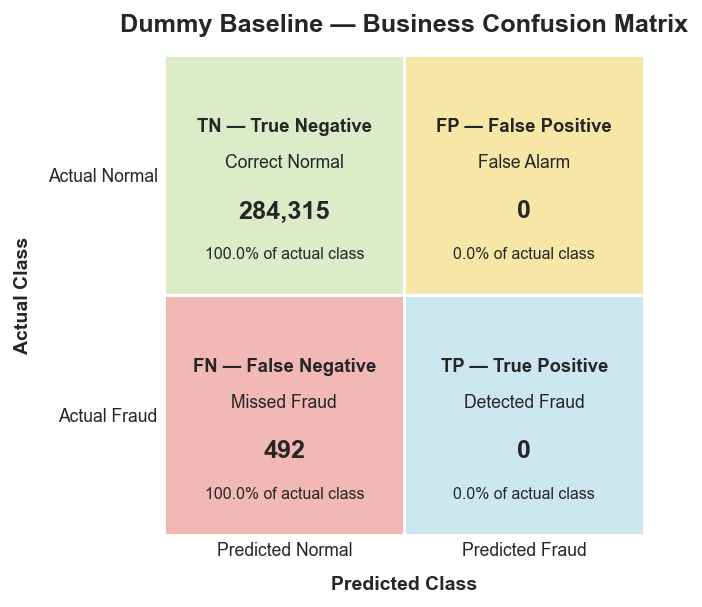

In [7]:
# ------------------------------------------------------------
# Compact business-style confusion matrix for dummy baseline
# ------------------------------------------------------------

from sklearn.metrics import confusion_matrix
import matplotlib.patches as patches

# Calculate confusion matrix values
# Rows = actual classes, columns = predicted classes
cm_dummy = confusion_matrix(y_true, y_dummy)

# Extract confusion matrix values
# TN = True Negative, FP = False Positive
# FN = False Negative, TP = True Positive
tn, fp, fn, tp = cm_dummy.ravel()

# ------------------------------------------------------------
# Calculate row percentages
# ------------------------------------------------------------

# Total actual normal transactions
normal_total = tn + fp

# Total actual fraud transactions
fraud_total = fn + tp

# Percentage within actual normal class
tn_pct = tn / normal_total * 100
fp_pct = fp / normal_total * 100

# Percentage within actual fraud class
fn_pct = fn / fraud_total * 100
tp_pct = tp / fraud_total * 100

# ------------------------------------------------------------
# Prepare cell content
# ------------------------------------------------------------

cells = [
    {
        "x": 0,
        "y": 1,
        "title": "TN — True Negative",
        "subtitle": "Correct Normal",
        "count": tn,
        "pct": tn_pct,
        "color": "#DCECC9"
    },
    {
        "x": 1,
        "y": 1,
        "title": "FP — False Positive",
        "subtitle": "False Alarm",
        "count": fp,
        "pct": fp_pct,
        "color": "#F7E7A6"
    },
    {
        "x": 0,
        "y": 0,
        "title": "FN — False Negative",
        "subtitle": "Missed Fraud",
        "count": fn,
        "pct": fn_pct,
        "color": "#F2B8B5"
    },
    {
        "x": 1,
        "y": 0,
        "title": "TP — True Positive",
        "subtitle": "Detected Fraud",
        "count": tp,
        "pct": tp_pct,
        "color": "#CDE7F0"
    }
]

# ------------------------------------------------------------
# Create chart
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(6.2, 4.5), dpi=140)

# Draw each confusion matrix cell manually
for cell in cells:
    # Draw cell rectangle
    rect = patches.Rectangle(
        (cell["x"], cell["y"]),
        1,
        1,
        linewidth=1.5,
        edgecolor="white",
        facecolor=cell["color"]
    )
    ax.add_patch(rect)

    # Add confusion matrix terminology
    ax.text(
        cell["x"] + 0.5,
        cell["y"] + 0.70,
        cell["title"],
        ha="center",
        va="center",
        fontsize=9.5,
        fontweight="bold"
    )

    # Add business-friendly label
    ax.text(
        cell["x"] + 0.5,
        cell["y"] + 0.55,
        cell["subtitle"],
        ha="center",
        va="center",
        fontsize=9
    )

    # Add count
    ax.text(
        cell["x"] + 0.5,
        cell["y"] + 0.35,
        f'{cell["count"]:,}',
        ha="center",
        va="center",
        fontsize=13,
        fontweight="bold"
    )

    # Add row percentage
    ax.text(
        cell["x"] + 0.5,
        cell["y"] + 0.17,
        f'{cell["pct"]:.1f}% of actual class',
        ha="center",
        va="center",
        fontsize=8.2
    )

# ------------------------------------------------------------
# Axis formatting
# ------------------------------------------------------------

# Set chart limits and square layout
ax.set_xlim(0, 2)
ax.set_ylim(0, 2)
ax.set_aspect("equal")

# Add tick labels
ax.set_xticks([0.5, 1.5])
ax.set_xticklabels(["Predicted Normal", "Predicted Fraud"], fontsize=9)

ax.set_yticks([0.5, 1.5])
ax.set_yticklabels(["Actual Fraud", "Actual Normal"], fontsize=9)

# Add axis labels
ax.set_xlabel("Predicted Class", fontsize=10, fontweight="bold", labelpad=8)
ax.set_ylabel("Actual Class", fontsize=10, fontweight="bold", labelpad=8)

# Add title
ax.set_title(
    "Dummy Baseline — Business Confusion Matrix",
    fontsize=13,
    fontweight="bold",
    pad=12
)

# Remove unnecessary borders
for spine in ax.spines.values():
    spine.set_visible(False)

# Remove tick marks
ax.tick_params(length=0)

# Improve layout
plt.tight_layout()

# Show chart
plt.show()

### Interpretation

The dummy baseline predicts every transaction as normal.

The confusion matrix shows four possible outcomes:

- **TN — True Negative:** normal transaction correctly predicted as normal.
- **FP — False Positive:** normal transaction wrongly flagged as fraud.
- **FN — False Negative:** fraud transaction wrongly predicted as normal.
- **TP — True Positive:** fraud transaction correctly detected.

In this baseline, all 492 fraud cases become **False Negatives**. This means the model misses every fraud transaction.

Although the accuracy is very high, the model has no practical fraud-detection value because fraud Recall and F1-Score are both 0.

---

## 5. Train/Test Split

### Purpose

Before modelling, the dataset is split into a **training set** and a **test set**.

The training set is used to fit the model.  
The test set is kept untouched and used only for final evaluation.

### Why Stratification Is Required

Fraud cases are extremely rare in this dataset.  
Therefore, a normal random split could create train/test sets with slightly different fraud ratios.

To prevent this, we use **stratified splitting** with `stratify=y`.

This keeps the proportion of:

- normal transactions (`Class = 0`)
- fraudulent transactions (`Class = 1`)

approximately the same in both training and test data.

### Important Leakage Rule

Resampling methods such as **Random Oversampling**, **SMOTE**, **Random Undersampling**, and **Tomek Links** must be applied **only to the training data**.

The test set must remain untouched so that model performance reflects a realistic fraud-detection scenario.

---

In [8]:
# ------------------------------------------------------------
# Train/test split
# ------------------------------------------------------------

from sklearn.model_selection import train_test_split

# Separate features and target
# X contains all input columns used for prediction
# y contains the target variable we want to predict
X = df.drop(columns="Class")
y = df["Class"]

# Split the data into training and test sets
# stratify=y keeps the fraud/non-fraud ratio similar in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

# Confirm the split sizes
print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

Training set shape: (227845, 30)
Test set shape: (56962, 30)


In [9]:
# ------------------------------------------------------------
# Verify class distribution after stratified split
# ------------------------------------------------------------

split_check = pd.DataFrame({
    "Dataset": ["Training Set", "Test Set"],
    "Normal Count": [
        (y_train == 0).sum(),
        (y_test == 0).sum()
    ],
    "Fraud Count": [
        (y_train == 1).sum(),
        (y_test == 1).sum()
    ],
    "Fraud Percentage": [
        (y_train == 1).mean() * 100,
        (y_test == 1).mean() * 100
    ]
})

# Format for clean display
split_check_display = split_check.copy()
split_check_display["Normal Count"] = split_check_display["Normal Count"].map("{:,}".format)
split_check_display["Fraud Count"] = split_check_display["Fraud Count"].map("{:,}".format)
split_check_display["Fraud Percentage"] = split_check_display["Fraud Percentage"].map("{:.4f}%".format)

display(split_check_display)

,Dataset,Normal Count,Fraud Count,Fraud Percentage
0,Training Set,"227,451",394,0.1729%
1,Test Set,"56,864",98,0.1720%


### Split Validation

The stratified split preserved the original fraud ratio in both datasets.

The training set contains **394 fraud cases**, while the test set contains **98 fraud cases**.  
Both sets keep the fraud rate close to **0.17%**.

This confirms that the test set is representative and can be used later for fair model evaluation.

---

## 6. Feature Scaling

### Why Scaling Is Needed

Most features in this dataset are already PCA-transformed variables: `V1` to `V28`.

However, two columns are still in their original scale:

- `Time`
- `Amount`

These columns can have much larger value ranges than the PCA features.

### Why This Matters for SMOTE

SMOTE creates synthetic minority-class examples using nearest neighbours.  
Because it is distance-based, features with larger scales can dominate the distance calculation.

To avoid this, we scale `Time` and `Amount` before applying SMOTE.

### Leakage Prevention

The scaler is fitted only on the training data.  
The same fitted scaler is then applied to the test data.

This keeps the test set untouched and prevents data leakage.

---

In [10]:
# ------------------------------------------------------------
# Scale Time and Amount after train/test split
# ------------------------------------------------------------

from sklearn.preprocessing import RobustScaler

# Create copies so the original train/test sets remain unchanged
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# Columns that need scaling
# V1 to V28 are already PCA-transformed, so we only scale Time and Amount
scale_columns = ["Time", "Amount"]

# RobustScaler is suitable because transaction Amount can be highly skewed
scaler = RobustScaler()

# Fit the scaler only on training data to avoid data leakage
X_train_scaled[scale_columns] = scaler.fit_transform(X_train[scale_columns])

# Apply the same fitted scaler to the test data
X_test_scaled[scale_columns] = scaler.transform(X_test[scale_columns])

# Quick validation table
scaling_check = pd.DataFrame({
    "Column": scale_columns,
    "Median Before Scaling": X_train[scale_columns].median().values,
    "Median After Scaling": X_train_scaled[scale_columns].median().values,
    "IQR After Scaling": (
        X_train_scaled[scale_columns].quantile(0.75) 
        - X_train_scaled[scale_columns].quantile(0.25)
    ).values
})

display(scaling_check)

,Column,Median Before Scaling,Median After Scaling,IQR After Scaling
0,Time,84805.0000,0.0000,1.0000
1,Amount,22.0000,0.0000,1.0000


---

### Scaling Summary

`Time` and `Amount` were scaled after the train/test split using `RobustScaler`.

The validation table confirms that both columns now have:

* a median close to **0**
* an interquartile range close to **1**

This means the scaling step worked as expected.

This preprocessing is especially important before applying distance-based resampling methods such as **SMOTE**, because unscaled features with large value ranges can dominate nearest-neighbour calculations.

The scaler was fitted only on the training data and then applied to the test data.
This prevents data leakage and keeps the test set suitable for realistic model evaluation.

---


---

## 7. Resampling Methods

### Objective

The training data is highly imbalanced, with fraud transactions representing only a very small share of all records.

To improve minority-class learning, we will compare four resampling strategies:

| Method                   | Purpose                                                                   |
| ------------------------ | ------------------------------------------------------------------------- |
| **Random Oversampling**  | Duplicates fraud examples to balance the training data                    |
| **SMOTE**                | Creates synthetic fraud-like examples using nearest neighbours            |
| **Random Undersampling** | Reduces normal transactions by removing majority-class samples            |
| **Tomek Links**          | Cleans the decision boundary by removing ambiguous majority-class samples |

### Leakage Control

All resampling methods will be applied **only to the training data**.

The test set remains unchanged so that model evaluation reflects real-world fraud detection, where fraud cases are naturally rare.

---


In [11]:
# ------------------------------------------------------------
# Install imbalanced-learn
# ------------------------------------------------------------

# The import name is "imblearn", but the package name is "imbalanced-learn".
# We need this library for Random Oversampling, SMOTE, Random Undersampling,
# and Tomek Links.

#%pip install -q imbalanced-learn

# Quick import test
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler, TomekLinks

print("imbalanced-learn installed and imported successfully.")

imbalanced-learn installed and imported successfully.


In [12]:
# ------------------------------------------------------------
# Random Oversampling
# ------------------------------------------------------------

from imblearn.over_sampling import RandomOverSampler

# Random Oversampling duplicates minority-class samples
# until both classes have the same number of records.
ros = RandomOverSampler(random_state=RANDOM_STATE)

# Apply oversampling only to the training data
# The test data must remain untouched.
X_train_ros, y_train_ros = ros.fit_resample(X_train_scaled, y_train)

# Create before/after comparison table
ros_summary = pd.DataFrame({
    "Dataset": [
        "Original Training Set",
        "Original Training Set",
        "After Random Oversampling",
        "After Random Oversampling"
    ],
    "Class": [0, 1, 0, 1],
    "Meaning": [
        "Normal Transaction",
        "Fraud Transaction",
        "Normal Transaction",
        "Fraud Transaction"
    ],
    "Count": [
        (y_train == 0).sum(),
        (y_train == 1).sum(),
        (y_train_ros == 0).sum(),
        (y_train_ros == 1).sum()
    ],
    "Percentage": [
        (y_train == 0).mean() * 100,
        (y_train == 1).mean() * 100,
        (y_train_ros == 0).mean() * 100,
        (y_train_ros == 1).mean() * 100
    ]
})

# Format for clean display
ros_summary_display = ros_summary.copy()
ros_summary_display["Count"] = ros_summary_display["Count"].map("{:,}".format)
ros_summary_display["Percentage"] = ros_summary_display["Percentage"].map("{:.4f}%".format)

display(ros_summary_display)

print("Original training shape:", X_train_scaled.shape)
print("After Random Oversampling shape:", X_train_ros.shape)

,Dataset,Class,Meaning,Count,Percentage
0,Original Training Set,0,Normal Transaction,"227,451",99.8271%
1,Original Training Set,1,Fraud Transaction,394,0.1729%
2,After Random Oversampling,0,Normal Transaction,"227,451",50.0000%
3,After Random Oversampling,1,Fraud Transaction,"227,451",50.0000%


Original training shape: (227845, 30)
After Random Oversampling shape: (454902, 30)


---

### Random Oversampling — Result Summary

Random Oversampling successfully balanced the training data.

| Stage | Normal Transactions | Fraud Transactions | Result |
|---|---:|---:|---|
| Before Oversampling | 227,451 | 394 | Highly imbalanced |
| After Oversampling | 227,451 | 227,451 | Balanced training set |

#### Interpretation

Random Oversampling increases the number of fraud examples by duplicating existing minority-class records.

This helps the model see fraud cases more frequently during training.  
However, the additional fraud records are copies of existing observations, not new transaction patterns.

#### Key Limitation

Because duplicated fraud cases appear many times, the model may memorise specific fraud examples.

This can increase the risk of **overfitting**, where the model performs well on training data but generalises poorly to unseen transactions.

#### Evaluation Rule

The test set remains unchanged and imbalanced.

This is important because real-world fraud detection data is naturally imbalanced, and model performance must be evaluated under realistic conditions.

---

---

## 8. SMOTE — Synthetic Minority Oversampling

### Objective

Random Oversampling balances the data by copying existing fraud transactions.

SMOTE takes a better approach.  
Instead of copying fraud cases, it creates **new synthetic fraud-like examples**.

### Simple Example

Suppose the training data has only three fraud transactions that look similar:

| Transaction | Amount Pattern | Behaviour |
|---|---|---|
| Fraud A | Medium amount | Unusual timing |
| Fraud B | Slightly higher amount | Similar unusual timing |
| Fraud C | Medium amount | Similar behaviour |

Random Oversampling would simply copy these same fraud cases again and again.

SMOTE creates new artificial fraud examples between similar fraud cases.  
So instead of memorising only Fraud A, B, and C, the model sees more possible fraud-like patterns.

### Why This Helps

This can help the model learn a wider fraud region instead of memorising duplicated rows.

However, SMOTE still needs care. If the original fraud examples are noisy, SMOTE may also create unrealistic synthetic fraud cases.

### Key Rule

SMOTE must be applied only to the **training data**.

The test set stays unchanged and imbalanced because it should represent real-world unseen transactions.

---

In [13]:
# ------------------------------------------------------------
# SMOTE — Synthetic Minority Oversampling
# ------------------------------------------------------------

from imblearn.over_sampling import SMOTE

# SMOTE creates synthetic minority-class samples instead of duplicating rows.
# It uses nearest neighbours, so we apply it to the scaled training data.
smote = SMOTE(random_state=RANDOM_STATE)

# Apply SMOTE only to the training data.
# The test set remains unchanged for realistic evaluation.
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

# Create a clean before/after comparison table
smote_summary = pd.DataFrame({
    "Stage": [
        "Before SMOTE",
        "Before SMOTE",
        "After SMOTE",
        "After SMOTE"
    ],
    "Class": [0, 1, 0, 1],
    "Meaning": [
        "Normal Transaction",
        "Fraud Transaction",
        "Normal Transaction",
        "Fraud Transaction"
    ],
    "Count": [
        (y_train == 0).sum(),
        (y_train == 1).sum(),
        (y_train_smote == 0).sum(),
        (y_train_smote == 1).sum()
    ],
    "Percentage": [
        (y_train == 0).mean() * 100,
        (y_train == 1).mean() * 100,
        (y_train_smote == 0).mean() * 100,
        (y_train_smote == 1).mean() * 100
    ]
})

# Format table for notebook display
smote_summary_display = smote_summary.copy()
smote_summary_display["Count"] = smote_summary_display["Count"].map("{:,}".format)
smote_summary_display["Percentage"] = smote_summary_display["Percentage"].map("{:.4f}%".format)

display(smote_summary_display)

print("Original training shape:", X_train_scaled.shape)
print("After SMOTE shape:", X_train_smote.shape)

,Stage,Class,Meaning,Count,Percentage
0,Before SMOTE,0,Normal Transaction,"227,451",99.8271%
1,Before SMOTE,1,Fraud Transaction,394,0.1729%
2,After SMOTE,0,Normal Transaction,"227,451",50.0000%
3,After SMOTE,1,Fraud Transaction,"227,451",50.0000%


Original training shape: (227845, 30)
After SMOTE shape: (454902, 30)


---

### SMOTE — Result Summary

SMOTE successfully balanced the training data.

| Stage | Normal Transactions | Fraud Transactions | Result |
|---|---:|---:|---|
| Before SMOTE | 227,451 | 394 | Highly imbalanced |
| After SMOTE | 227,451 | 227,451 | Balanced training set |

### Interpretation

Unlike Random Oversampling, SMOTE does not simply copy the existing fraud transactions.

It creates new synthetic fraud-like examples between similar minority-class observations.  
This gives the model a wider range of fraud patterns to learn from.

### Important Limitation

SMOTE can improve minority-class learning, but it can also create unrealistic fraud examples if the original fraud cases are noisy or very different from each other.

### Evaluation Rule

The test set remains unchanged and imbalanced.

This is important because real fraud detection systems also receive naturally imbalanced transaction data.

---

---

## 9. Random Undersampling

### Objective

Random Undersampling balances the training data by reducing the majority class.

In this dataset, the majority class is normal transactions.  
The minority class is fraud transactions.

### Simple Example

Suppose the training data looks like this:

| Class | Count |
|---|---:|
| Normal Transactions | 10,000 |
| Fraud Transactions | 100 |

Random Undersampling randomly removes normal transactions until both classes have the same size:

| Class | Count After Undersampling |
|---|---:|
| Normal Transactions | 100 |
| Fraud Transactions | 100 |

### Why This Helps

The model sees a balanced dataset and pays more attention to fraud cases.

### Important Limitation

Random Undersampling removes many normal transactions.

This can cause information loss because normal customer behaviour may have many different patterns.

### Key Rule

Undersampling is applied only to the **training data**.

The test set remains unchanged and imbalanced for realistic evaluation.

---

In [14]:
# ------------------------------------------------------------
# Random Undersampling
# ------------------------------------------------------------

from imblearn.under_sampling import RandomUnderSampler

# Random Undersampling removes majority-class samples
# until both classes have the same number of records.
rus = RandomUnderSampler(random_state=RANDOM_STATE)

# Apply undersampling only to the training data.
# The test set remains unchanged for realistic evaluation.
X_train_rus, y_train_rus = rus.fit_resample(X_train_scaled, y_train)

# Create a clean before/after comparison table
rus_summary = pd.DataFrame({
    "Stage": [
        "Before Undersampling",
        "Before Undersampling",
        "After Undersampling",
        "After Undersampling"
    ],
    "Class": [0, 1, 0, 1],
    "Meaning": [
        "Normal Transaction",
        "Fraud Transaction",
        "Normal Transaction",
        "Fraud Transaction"
    ],
    "Count": [
        (y_train == 0).sum(),
        (y_train == 1).sum(),
        (y_train_rus == 0).sum(),
        (y_train_rus == 1).sum()
    ],
    "Percentage": [
        (y_train == 0).mean() * 100,
        (y_train == 1).mean() * 100,
        (y_train_rus == 0).mean() * 100,
        (y_train_rus == 1).mean() * 100
    ]
})

# Format table for notebook display
rus_summary_display = rus_summary.copy()
rus_summary_display["Count"] = rus_summary_display["Count"].map("{:,}".format)
rus_summary_display["Percentage"] = rus_summary_display["Percentage"].map("{:.4f}%".format)

display(rus_summary_display)

print("Original training shape:", X_train_scaled.shape)
print("After Random Undersampling shape:", X_train_rus.shape)

,Stage,Class,Meaning,Count,Percentage
0,Before Undersampling,0,Normal Transaction,"227,451",99.8271%
1,Before Undersampling,1,Fraud Transaction,394,0.1729%
2,After Undersampling,0,Normal Transaction,394,50.0000%
3,After Undersampling,1,Fraud Transaction,394,50.0000%


Original training shape: (227845, 30)
After Random Undersampling shape: (788, 30)


---

### Random Undersampling — Result Summary

Random Undersampling successfully balanced the training data by reducing the majority class.

| Stage | Normal Transactions | Fraud Transactions | Result |
|---|---:|---:|---|
| Before Undersampling | 227,451 | 394 | Highly imbalanced |
| After Undersampling | 394 | 394 | Balanced training set |

### Interpretation

Random Undersampling makes the dataset balanced by removing normal transactions.

This helps the model focus more equally on fraud and normal cases.

### Important Limitation

The main drawback is information loss.

In this case, the training data was reduced from **227,845 rows** to only **788 rows**.  
That means many normal transaction patterns were removed.

This can make the model faster to train, but it may also become less stable and less representative of real customer behaviour.

### Evaluation Rule

The test set remains unchanged and imbalanced.

This allows us to check whether the model trained on a small balanced sample can still perform well on realistic unseen data.

---

---

## 10. Tomek Links

### Objective

Tomek Links are used to clean the boundary between classes.

Unlike oversampling or undersampling, Tomek Links do not try to fully balance the dataset.  
They remove majority-class samples that are very close to minority-class samples.

### Simple Example

Imagine one normal transaction and one fraud transaction are almost identical.

| Transaction | Class | Situation |
|---|---|---|
| Transaction A | Normal | Very close to fraud |
| Transaction B | Fraud | Very close to normal |

This pair is difficult for the model because both classes overlap in the same area.

Tomek Links remove the majority-class example from such pairs.  
In this project, that means removing confusing normal transactions near fraud transactions.

### Why This Helps

Removing these borderline normal transactions can make the decision boundary cleaner.

This may help the model separate fraud and normal transactions more clearly.

### Important Limitation

Tomek Links usually do not create a perfectly balanced dataset.

They are mainly a cleaning method, not a full balancing method.

### Key Rule

Tomek Links are applied only to the **training data**.

The test set remains unchanged and imbalanced for realistic evaluation.

---

In [15]:
# ------------------------------------------------------------
# Tomek Links
# ------------------------------------------------------------

from imblearn.under_sampling import TomekLinks

# Tomek Links remove majority-class samples that are very close
# to minority-class samples near the decision boundary.
#
# This method cleans the training data but usually does not fully balance it.
tl = TomekLinks(sampling_strategy="majority")

# Apply Tomek Links only to the training data.
# The test set remains unchanged for realistic evaluation.
X_train_tl, y_train_tl = tl.fit_resample(X_train_scaled, y_train)

# Create a clean before/after comparison table
tl_summary = pd.DataFrame({
    "Stage": [
        "Before Tomek Links",
        "Before Tomek Links",
        "After Tomek Links",
        "After Tomek Links"
    ],
    "Class": [0, 1, 0, 1],
    "Meaning": [
        "Normal Transaction",
        "Fraud Transaction",
        "Normal Transaction",
        "Fraud Transaction"
    ],
    "Count": [
        (y_train == 0).sum(),
        (y_train == 1).sum(),
        (y_train_tl == 0).sum(),
        (y_train_tl == 1).sum()
    ],
    "Percentage": [
        (y_train == 0).mean() * 100,
        (y_train == 1).mean() * 100,
        (y_train_tl == 0).mean() * 100,
        (y_train_tl == 1).mean() * 100
    ]
})

# Format table for notebook display
tl_summary_display = tl_summary.copy()
tl_summary_display["Count"] = tl_summary_display["Count"].map("{:,}".format)
tl_summary_display["Percentage"] = tl_summary_display["Percentage"].map("{:.4f}%".format)

display(tl_summary_display)

print("Original training shape:", X_train_scaled.shape)
print("After Tomek Links shape:", X_train_tl.shape)

,Stage,Class,Meaning,Count,Percentage
0,Before Tomek Links,0,Normal Transaction,"227,451",99.8271%
1,Before Tomek Links,1,Fraud Transaction,394,0.1729%
2,After Tomek Links,0,Normal Transaction,"227,431",99.8271%
3,After Tomek Links,1,Fraud Transaction,394,0.1729%


Original training shape: (227845, 30)
After Tomek Links shape: (227825, 30)


---

### Tomek Links — Result Summary

Tomek Links cleaned the training data by removing a small number of majority-class samples near the class boundary.

| Stage | Normal Transactions | Fraud Transactions | Result |
|---|---:|---:|---|
| Before Tomek Links | 227,451 | 394 | Highly imbalanced |
| After Tomek Links | 227,431 | 394 | Slightly cleaned |

### Interpretation

Tomek Links removed **20 normal transactions** from the training data.

These removed samples were majority-class examples located very close to minority-class fraud examples.  
Such points can make the decision boundary harder for the model to learn.

### Key Difference

Tomek Links does **not** fully balance the dataset.

Instead, it slightly cleans the majority class by removing borderline examples that may confuse the classifier.

### Practical Note

Tomek Links can take longer to run on large datasets because it uses nearest-neighbour calculations.

In this project, it is included as a boundary-cleaning method and will be compared with the other resampling strategies during model evaluation.

---

In [16]:
# ------------------------------------------------------------
# Resampling comparison summary
# ------------------------------------------------------------

def summarize_resampled_data(y_values, method_name):
    """
    Create a compact class distribution summary for one dataset version.
    
    Parameters
    ----------
    y_values : pandas Series or array-like
        Target values after a resampling method.
    method_name : str
        Name of the resampling method.
    """
    
    # Convert to Series so value_counts works consistently
    y_series = pd.Series(y_values)
    
    # Count each class
    counts = y_series.value_counts().sort_index()
    
    # Calculate percentage share of each class
    percentages = y_series.value_counts(normalize=True).sort_index() * 100
    
    return pd.DataFrame({
        "Method": method_name,
        "Normal Count": [counts.get(0, 0)],
        "Fraud Count": [counts.get(1, 0)],
        "Fraud Percentage": [percentages.get(1, 0)]
    })


# Create one summary row for each training dataset version
resampling_comparison = pd.concat([
    summarize_resampled_data(y_train, "Original Training Data"),
    summarize_resampled_data(y_train_ros, "Random Oversampling"),
    summarize_resampled_data(y_train_smote, "SMOTE"),
    summarize_resampled_data(y_train_rus, "Random Undersampling"),
    summarize_resampled_data(y_train_tl, "Tomek Links")
], ignore_index=True)

# Format display version for notebook readability
resampling_comparison_display = resampling_comparison.copy()
resampling_comparison_display["Normal Count"] = resampling_comparison_display["Normal Count"].map("{:,}".format)
resampling_comparison_display["Fraud Count"] = resampling_comparison_display["Fraud Count"].map("{:,}".format)
resampling_comparison_display["Fraud Percentage"] = resampling_comparison_display["Fraud Percentage"].map("{:.4f}%".format)

display(resampling_comparison_display)

,Method,Normal Count,Fraud Count,Fraud Percentage
0,Original Training Data,"227,451",394,0.1729%
1,Random Oversampling,"227,451","227,451",50.0000%
2,SMOTE,"227,451","227,451",50.0000%
3,Random Undersampling,394,394,50.0000%
4,Tomek Links,"227,431",394,0.1729%


- Random Oversampling → balances by duplication
- SMOTE → balances by synthetic fraud examples
- Random Undersampling → balances by removing most normal examples
- Tomek Links → cleans only a few boundary samples, does not balance

---

### Resampling Comparison — Summary

The resampling methods produced different versions of the training data.

| Method | Main Effect |
|---|---|
| Original Training Data | Keeps the natural imbalance |
| Random Oversampling | Balances the data by duplicating fraud cases |
| SMOTE | Balances the data by creating synthetic fraud-like cases |
| Random Undersampling | Balances the data by removing most normal cases |
| Tomek Links | Slightly cleans the majority class but keeps the dataset imbalanced |

### Key Observation

Random Oversampling and SMOTE both create balanced training datasets with a 50:50 class ratio.

Random Undersampling also creates a balanced dataset, but it reduces the training data from **227,845 rows** to only **788 rows**.

Tomek Links removes only **20 normal transactions**, so it behaves more like a boundary-cleaning technique than a balancing method.

### Next Step

The next step is to train the same model on each training dataset version and compare performance on the unchanged test set.

This will show whether balancing the training data actually improves fraud detection.

---

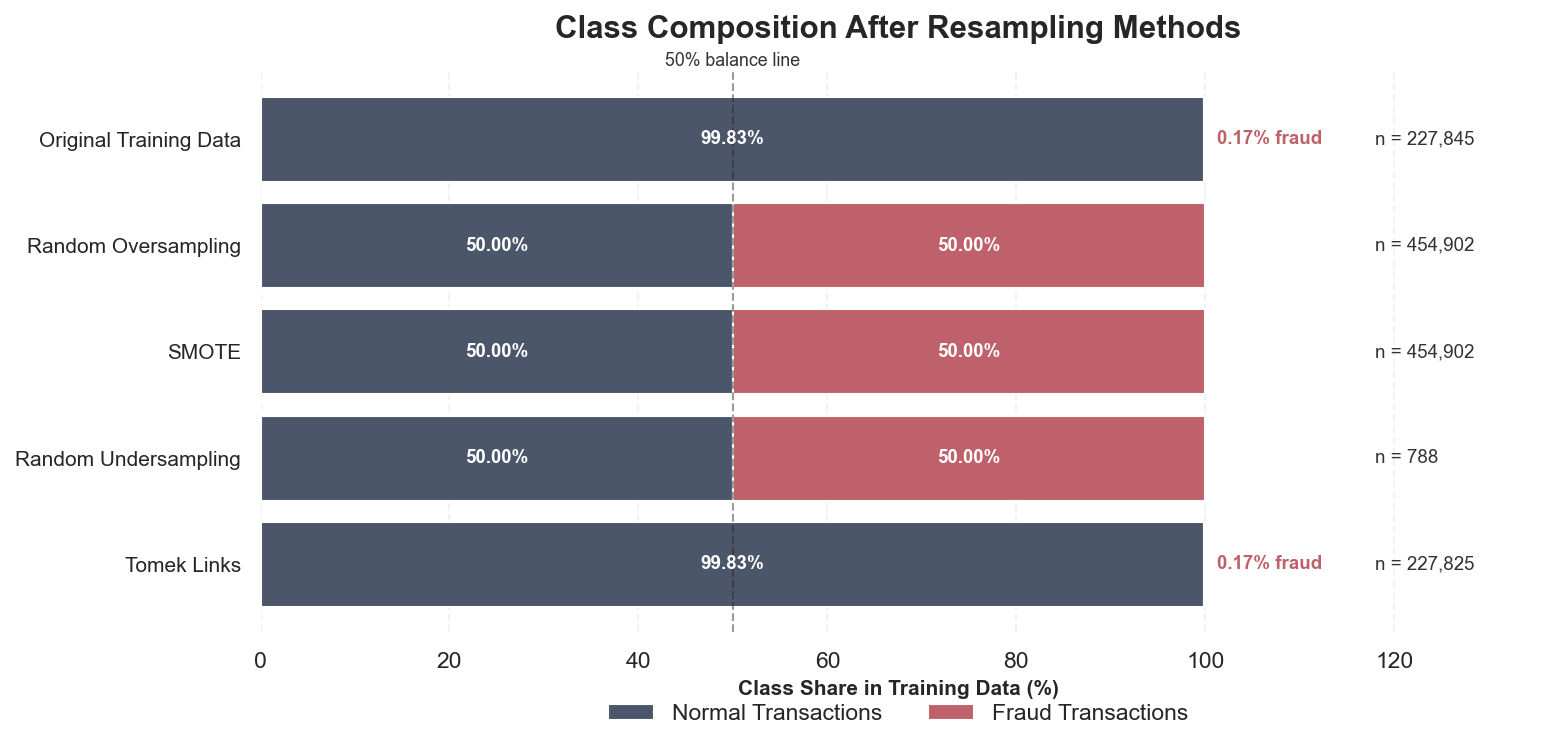

In [17]:
# ------------------------------------------------------------
# Professional chart: class composition after resampling
# ------------------------------------------------------------

# Prepare plotting data
plot_df = resampling_comparison.copy()

# Keep logical order
method_order = [
    "Original Training Data",
    "Random Oversampling",
    "SMOTE",
    "Random Undersampling",
    "Tomek Links"
]

plot_df["Method"] = pd.Categorical(
    plot_df["Method"],
    categories=method_order,
    ordered=True
)

plot_df = plot_df.sort_values("Method").reset_index(drop=True)

# Calculate percentages
plot_df["Total Samples"] = plot_df["Normal Count"] + plot_df["Fraud Count"]
plot_df["Normal Percentage"] = plot_df["Normal Count"] / plot_df["Total Samples"] * 100
plot_df["Fraud Percentage"] = plot_df["Fraud Count"] / plot_df["Total Samples"] * 100

# Create figure
fig, ax = plt.subplots(figsize=(10.5, 5.2), dpi=150)

# Y positions
y_positions = np.arange(len(plot_df))

# Colors
normal_color = "#4C566A"
fraud_color = "#BF616A"

# Plot 100% stacked horizontal bars
ax.barh(
    y_positions,
    plot_df["Normal Percentage"],
    color=normal_color,
    label="Normal Transactions"
)

ax.barh(
    y_positions,
    plot_df["Fraud Percentage"],
    left=plot_df["Normal Percentage"],
    color=fraud_color,
    label="Fraud Transactions"
)

# Add method labels
ax.set_yticks(y_positions)
ax.set_yticklabels(plot_df["Method"], fontsize=10)
ax.invert_yaxis()

# Add percentage labels inside or beside bars
for i, row in plot_df.iterrows():
    
    # Normal percentage label
    ax.text(
        row["Normal Percentage"] / 2,
        i,
        f'{row["Normal Percentage"]:.2f}%',
        ha="center",
        va="center",
        color="white",
        fontsize=9,
        fontweight="bold"
    )
    
    # Fraud percentage label
    if row["Fraud Percentage"] >= 5:
        ax.text(
            row["Normal Percentage"] + row["Fraud Percentage"] / 2,
            i,
            f'{row["Fraud Percentage"]:.2f}%',
            ha="center",
            va="center",
            color="white",
            fontsize=9,
            fontweight="bold"
        )
    else:
        ax.text(
            101.2,
            i,
            f'{row["Fraud Percentage"]:.2f}% fraud',
            ha="left",
            va="center",
            fontsize=9,
            fontweight="bold",
            color=fraud_color
        )
    
    # Total sample size annotation
    ax.text(
        118,
        i,
        f'n = {row["Total Samples"]:,}',
        ha="left",
        va="center",
        fontsize=9,
        color="#333333"
    )

# Formatting
ax.set_xlim(0, 135)

ax.set_title(
    "Class Composition After Resampling Methods",
    fontsize=15,
    fontweight="bold",
    pad=16
)

ax.set_xlabel("Class Share in Training Data (%)", fontsize=10, fontweight="bold")
ax.set_ylabel("")

# Add reference line at 50%
ax.axvline(
    50,
    color="#222222",
    linestyle="--",
    linewidth=1,
    alpha=0.45
)

ax.text(
    50,
    -0.65,
    "50% balance line",
    ha="center",
    va="bottom",
    fontsize=8.5,
    color="#333333"
)

# Legend
ax.legend(
    loc="lower center",
    bbox_to_anchor=(0.5, -0.20),
    ncol=2,
    frameon=False
)

# Clean up borders and grid
ax.grid(axis="x", linestyle="--", alpha=0.25)
ax.grid(axis="y", visible=False)

sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

---

## 11. Model Evaluation Setup

### Objective

We now prepare a reusable evaluation function.

The same model will be trained on different versions of the training data:

- original imbalanced data
- Random Oversampling data
- SMOTE data
- Random Undersampling data
- Tomek Links data

### Why This Is Needed

Using the same evaluation function keeps the comparison fair and consistent.

Each model will be evaluated on the same unchanged test set.

### Metrics Used

| Metric | Why It Matters |
|---|---|
| **Accuracy** | Shows overall correctness, but can be misleading for imbalanced data |
| **Precision** | Shows how many predicted fraud cases were actually fraud |
| **Recall** | Shows how many real fraud cases were detected |
| **F1-Score** | Balances Precision and Recall |
| **ROC-AUC** | Shows how well the model separates fraud and normal transactions |

### Key Rule

The test set remains unchanged and imbalanced.

This ensures that model performance is measured under realistic fraud-detection conditions.

---

In [18]:
# ------------------------------------------------------------
# Reusable model evaluation function
# ------------------------------------------------------------

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

def evaluate_model(model, X_test, y_test, model_name):
    """
    Evaluate a trained classification model on the unchanged test set.

    Parameters
    ----------
    model : fitted sklearn-compatible model
        The trained classification model.
    X_test : pandas DataFrame
        Unchanged test features.
    y_test : pandas Series
        True test labels.
    model_name : str
        Name used to identify the model in the results table.

    Returns
    -------
    pandas DataFrame
        One-row table containing key classification metrics.
    """

    # Predict class labels: 0 = normal, 1 = fraud
    y_pred = model.predict(X_test)

    # Predict fraud probabilities for ROC-AUC
    y_proba = model.predict_proba(X_test)[:, 1]

    # Store metrics in a clean table format
    results = pd.DataFrame({
        "Model": [model_name],
        "Accuracy": [accuracy_score(y_test, y_pred)],
        "Precision": [precision_score(y_test, y_pred, zero_division=0)],
        "Recall": [recall_score(y_test, y_pred, zero_division=0)],
        "F1-Score": [f1_score(y_test, y_pred, zero_division=0)],
        "ROC-AUC": [roc_auc_score(y_test, y_proba)]
    })

    return results

print("Evaluation function created successfully.")

Evaluation function created successfully.


---

## 12. Random Forest Model Comparison

### Objective

We now train the same Random Forest model on each training dataset version.

This allows us to compare whether resampling improves fraud detection.

### Training Versions

| Version | Description |
|---|---|
| Original | No resampling |
| Random Oversampling | Fraud cases duplicated |
| SMOTE | Synthetic fraud-like cases created |
| Random Undersampling | Majority class reduced |
| Tomek Links | Majority boundary samples cleaned |

### Evaluation Rule

All models are evaluated on the same unchanged test set.

This keeps the comparison fair and realistic.

---

In [19]:
# ------------------------------------------------------------
# Train Random Forest models on all training-data versions
# ------------------------------------------------------------

from sklearn.ensemble import RandomForestClassifier

# Store each training-data version in one dictionary
training_versions = {
    "Original": (X_train_scaled, y_train),
    "Random Oversampling": (X_train_ros, y_train_ros),
    "SMOTE": (X_train_smote, y_train_smote),
    "Random Undersampling": (X_train_rus, y_train_rus),
    "Tomek Links": (X_train_tl, y_train_tl)
}

# Dictionary to store fitted Random Forest models
rf_models = {}

# Train one model per training-data version
for version_name, (X_train_version, y_train_version) in training_versions.items():
    
    print(f"Training Random Forest on: {version_name}")
    
    # Random Forest model
    # n_estimators=50 keeps runtime manageable
    # n_jobs=-1 uses all available CPU cores
    rf_model = RandomForestClassifier(
        n_estimators=50,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    
    # Fit the model on the current training-data version
    rf_model.fit(X_train_version, y_train_version)
    
    # Save the trained model for later evaluation
    rf_models[version_name] = rf_model

print("\nAll Random Forest models trained successfully.")

Training Random Forest on: Original
Training Random Forest on: Random Oversampling
Training Random Forest on: SMOTE
Training Random Forest on: Random Undersampling
Training Random Forest on: Tomek Links

All Random Forest models trained successfully.


In [20]:
# ------------------------------------------------------------
# Evaluate trained Random Forest models on unchanged test data
# ------------------------------------------------------------

# Store model evaluation results
rf_results = []

# Evaluate each trained model on the same test set
for version_name, model in rf_models.items():
    
    print(f"Evaluating Random Forest — {version_name}")
    
    result = evaluate_model(
        model=model,
        X_test=X_test_scaled,
        y_test=y_test,
        model_name=f"Random Forest — {version_name}"
    )
    
    rf_results.append(result)

# Combine all results into one table
rf_results_table = pd.concat(rf_results, ignore_index=True)

# Create a formatted display version
rf_results_display = rf_results_table.copy()

for metric in ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]:
    rf_results_display[metric] = rf_results_display[metric].map(lambda x: f"{x:.4f}")

display(rf_results_display)

Evaluating Random Forest — Original
Evaluating Random Forest — Random Oversampling
Evaluating Random Forest — SMOTE
Evaluating Random Forest — Random Undersampling
Evaluating Random Forest — Tomek Links


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Random Forest — Original,0.9996,0.9412,0.8163,0.8743,0.9533
1,Random Forest — Random Oversampling,0.9996,0.9625,0.7857,0.8652,0.9583
2,Random Forest — SMOTE,0.9995,0.8602,0.8163,0.8377,0.9703
3,Random Forest — Random Undersampling,0.9634,0.0411,0.9082,0.0787,0.9774
4,Random Forest — Tomek Links,0.9996,0.9419,0.8265,0.8804,0.9583


---

### Random Forest Comparison — Result Summary

The Random Forest models were trained on five different versions of the training data and evaluated on the same unchanged test set.

| Best Metric | Best Method | Interpretation |
|---|---|---|
| **Best F1-Score** | Tomek Links | Best balance between Precision and Recall |
| **Best Recall** | Random Undersampling | Detects the most fraud cases |
| **Best ROC-AUC** | Random Undersampling | Strong ranking ability across thresholds |
| **Best Precision** | Random Oversampling | Lowest false-alarm rate among predicted fraud cases |

### Interpretation

The original Random Forest already performs strongly despite the severe class imbalance.

Tomek Links gives the best F1-Score, meaning it provides the best balance between detecting fraud and avoiding false alarms.

Random Undersampling gives the highest Recall, meaning it catches the most fraud cases.  
However, its Precision is very low, which means many normal transactions are incorrectly flagged as fraud.

### Business Meaning

For real-time fraud detection, high Recall is important because missed fraud can be costly.

However, very low Precision is also problematic because it can create too many false alerts and disturb normal customers.

At this stage, **Tomek Links appears to be the strongest balanced option**, while **Random Undersampling is more aggressive but less practical due to false alarms**.

---

---

## 13. Random Forest Metric Comparison

### Objective

The results table gives the exact metric values.

The next chart helps compare model performance visually across the most important fraud-detection metrics.

### Focus

For imbalanced fraud detection, we focus mainly on:

| Metric | Meaning |
|---|---|
| **Precision** | How reliable fraud alerts are |
| **Recall** | How many real fraud cases are detected |
| **F1-Score** | Balance between Precision and Recall |
| **ROC-AUC** | Overall fraud-vs-normal separation ability |

Accuracy is not the main focus because it can remain very high even when fraud detection is weak.

---

In [21]:
# ------------------------------------------------------------
# Professional HTML scorecard table — no pandas Styler required
# ------------------------------------------------------------

from IPython.display import HTML, display

# Prepare scorecard data
scorecard = rf_results_table.copy()

# Clean model names
scorecard["Model"] = scorecard["Model"].str.replace("Random Forest — ", "", regex=False)

# Add practical interpretation
interpretations = {
    "Original": "Strong baseline with high precision and good recall",
    "Random Oversampling": "Very reliable fraud alerts, but slightly lower recall",
    "SMOTE": "Good separation ability, but precision drops compared to baseline",
    "Random Undersampling": "Catches most fraud, but creates too many false alarms",
    "Tomek Links": "Best balanced Random Forest result"
}

scorecard["Business Interpretation"] = scorecard["Model"].map(interpretations)

# Rank by F1-Score because F1 balances Precision and Recall
scorecard["Rank"] = scorecard["F1-Score"].rank(ascending=False, method="dense").astype(int)

# Sort by F1 rank
scorecard = scorecard.sort_values("Rank").reset_index(drop=True)

# Metrics to display
metric_cols = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]

# Identify best value for each metric
best_values = {metric: scorecard[metric].max() for metric in metric_cols}

# Build HTML rows
rows_html = ""

for _, row in scorecard.iterrows():
    
    # Highlight best overall row based on F1-Score
    row_class = "best-row" if row["Rank"] == 1 else ""
    
    metric_cells = ""
    
    for metric in metric_cols:
        value = row[metric]
        is_best = value == best_values[metric]
        
        cell_class = "best-metric" if is_best else ""
        star = " ★" if is_best else ""
        
        metric_cells += f"""
        <td class="{cell_class}">
            <div class="metric-value">{value:.4f}{star}</div>
        </td>
        """
    
    rank_badge = "Winner" if row["Rank"] == 1 else f"Rank {row['Rank']}"
    
    rows_html += f"""
    <tr class="{row_class}">
        <td>
            <span class="rank-badge">{rank_badge}</span>
        </td>
        <td class="model-name">{row["Model"]}</td>
        {metric_cells}
        <td class="business-text">{row["Business Interpretation"]}</td>
    </tr>
    """

# Complete HTML table
html = f"""
<style>
.scorecard-container {{
    font-family: Arial, sans-serif;
    margin-top: 10px;
    max-width: 1200px;
}}

.scorecard-title {{
    font-size: 20px;
    font-weight: 700;
    color: #222;
    margin-bottom: 4px;
}}

.scorecard-subtitle {{
    font-size: 13px;
    color: #555;
    margin-bottom: 14px;
}}

.scorecard-table {{
    border-collapse: separate;
    border-spacing: 0;
    width: 100%;
    font-size: 13px;
    box-shadow: 0 2px 10px rgba(0,0,0,0.06);
    border-radius: 10px;
    overflow: hidden;
}}

.scorecard-table th {{
    background-color: #263238;
    color: white;
    text-align: center;
    padding: 11px 10px;
    font-weight: 700;
    border-right: 1px solid rgba(255,255,255,0.12);
}}

.scorecard-table th:first-child {{
    text-align: left;
}}

.scorecard-table td {{
    padding: 10px 10px;
    border-bottom: 1px solid #E6E9EF;
    text-align: center;
    background-color: #FFFFFF;
}}

.scorecard-table tr:nth-child(even) td {{
    background-color: #F8FAFC;
}}

.scorecard-table tr.best-row td {{
    background-color: #EAF7EA;
}}

.model-name {{
    text-align: left !important;
    font-weight: 700;
    color: #222;
}}

.metric-value {{
    font-weight: 600;
    color: #222;
}}

.best-metric {{
    background-color: #DCEEFF !important;
    color: #0B3D66;
    font-weight: 700;
}}

.rank-badge {{
    display: inline-block;
    padding: 4px 9px;
    border-radius: 999px;
    background-color: #ECEFF4;
    color: #333;
    font-size: 12px;
    font-weight: 700;
}}

.best-row .rank-badge {{
    background-color: #2E7D32;
    color: white;
}}

.business-text {{
    text-align: left !important;
    color: #333;
    line-height: 1.35;
    min-width: 260px;
}}

.scorecard-note {{
    margin-top: 10px;
    font-size: 12px;
    color: #555;
}}
</style>

<div class="scorecard-container">
    <div class="scorecard-title">Random Forest Model Comparison — Scorecard</div>
    <div class="scorecard-subtitle">
        All models are evaluated on the same unchanged imbalanced test set. 
        Ranking is based on F1-Score because it balances Precision and Recall.
    </div>

    <table class="scorecard-table">
        <thead>
            <tr>
                <th>Rank</th>
                <th>Training Data Version</th>
                <th>Accuracy</th>
                <th>Precision</th>
                <th>Recall</th>
                <th>F1-Score</th>
                <th>ROC-AUC</th>
                <th>Business Interpretation</th>
            </tr>
        </thead>
        <tbody>
            {rows_html}
        </tbody>
    </table>

    <div class="scorecard-note">
        ★ marks the best score for each metric. 
        Precision = fewer false alarms, Recall = more fraud detected, F1-Score = balance, ROC-AUC = separation ability.
    </div>
</div>
"""

display(HTML(html))

Rank,Training Data Version,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Business Interpretation
Winner,Tomek Links,0.9996 ★,0.9419,0.8265,0.8804 ★,0.9583,Best balanced Random Forest result
Rank 2,Original,0.9996,0.9412,0.8163,0.8743,0.9533,Strong baseline with high precision and good recall
Rank 3,Random Oversampling,0.9996,0.9625 ★,0.7857,0.8652,0.9583,"Very reliable fraud alerts, but slightly lower recall"
Rank 4,SMOTE,0.9995,0.8602,0.8163,0.8377,0.9703,"Good separation ability, but precision drops compared to baseline"
Rank 5,Random Undersampling,0.9634,0.0411,0.9082 ★,0.0787,0.9774 ★,"Catches most fraud, but creates too many false alarms"


---

## 14. ROC Curve Comparison

### Objective

The previous scorecard compared models using fixed-threshold metrics such as Precision, Recall, and F1-Score.

Now we compare the Random Forest models using **ROC curves**.

### Simple Explanation

A model usually produces a fraud probability first.

For example:

| Transaction | Fraud Probability |
|---|---:|
| A | 0.91 |
| B | 0.42 |
| C | 0.07 |

The decision threshold decides when a transaction becomes fraud.

If the threshold is `0.50`, only transaction A is classified as fraud.  
If the threshold is `0.30`, both A and B are classified as fraud.

The ROC curve shows how the model behaves when this threshold changes.

### Key Point

A higher ROC-AUC means the model separates fraud and normal transactions better overall.

However, ROC-AUC does not replace Precision, Recall, and F1-Score.  
For fraud detection, we still need to check false alarms and missed fraud cases carefully.

---

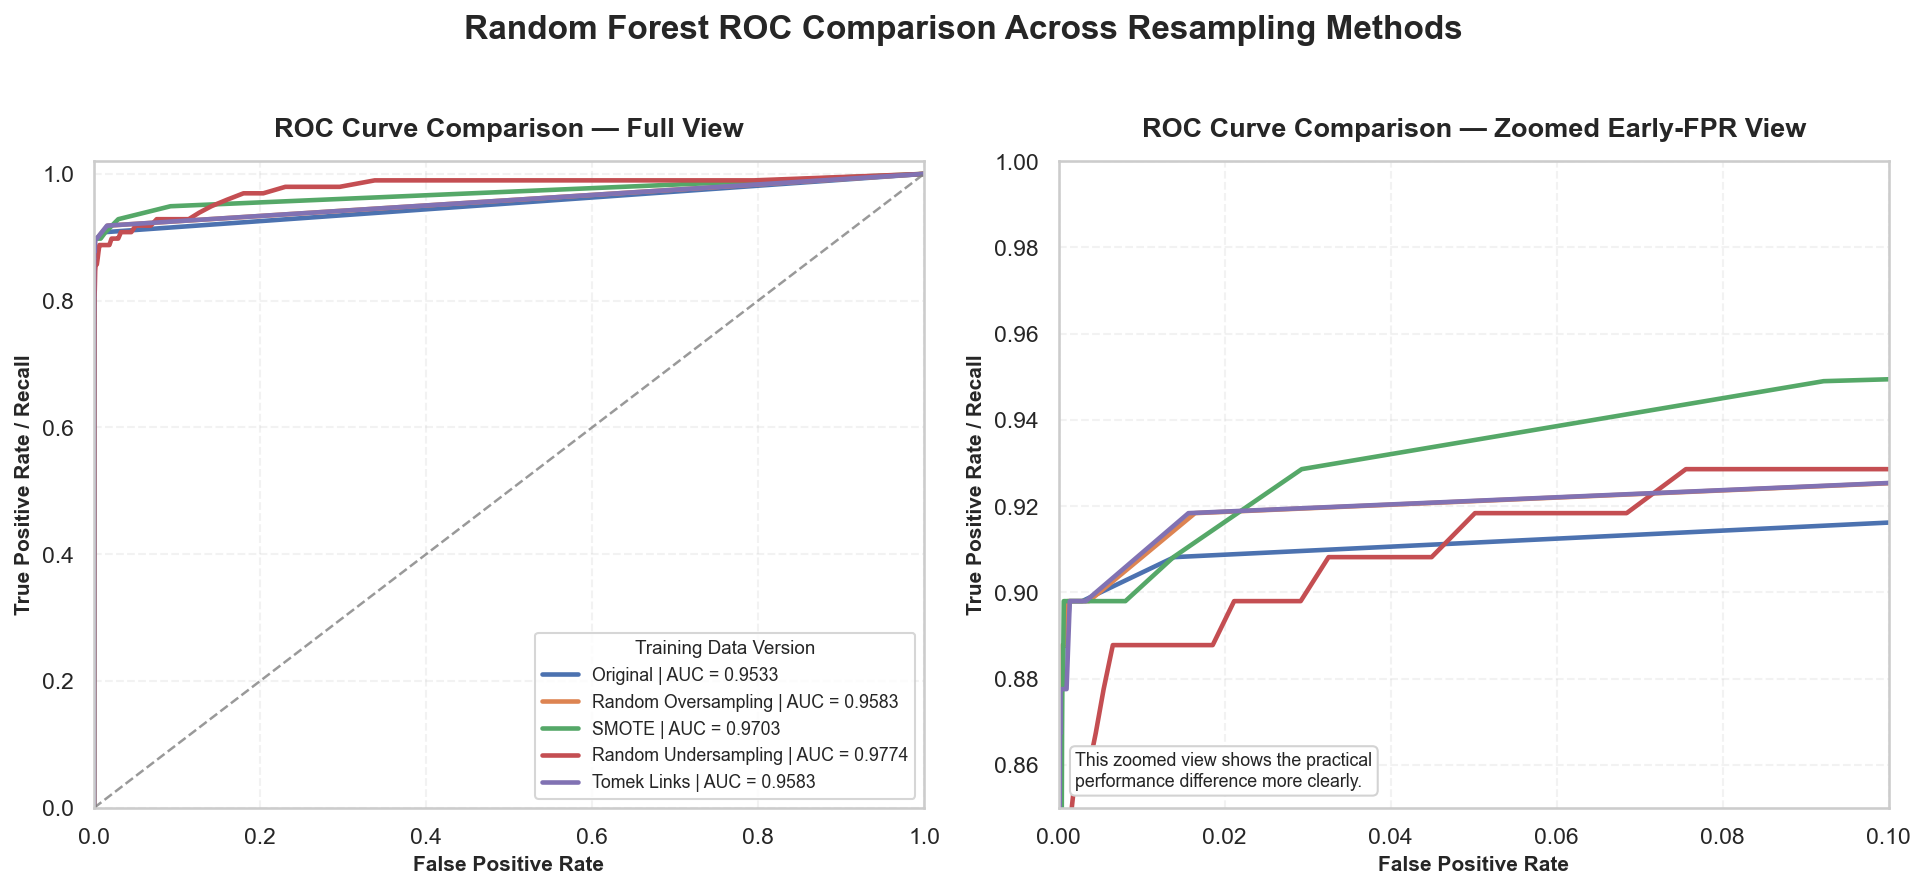

In [22]:
# ------------------------------------------------------------
# Improved ROC comparison chart
# Full view + zoomed-in view for low false positive rates
# ------------------------------------------------------------

from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Keep a logical display order
model_order = [
    "Original",
    "Random Oversampling",
    "SMOTE",
    "Random Undersampling",
    "Tomek Links"
]

# Create figure with two panels
fig, axes = plt.subplots(1, 2, figsize=(13, 5.8), dpi=150)

# Store AUC values for legend labels
auc_values = {}

# Plot curves
for model_name in model_order:
    model = rf_models[model_name]
    
    # Predicted fraud probabilities on unchanged test set
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    
    # ROC components
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc_score = roc_auc_score(y_test, y_proba)
    auc_values[model_name] = auc_score
    
    # Left panel: full ROC
    axes[0].plot(
        fpr,
        tpr,
        linewidth=2.2,
        label=f"{model_name} | AUC = {auc_score:.4f}"
    )
    
    # Right panel: zoomed ROC
    axes[1].plot(
        fpr,
        tpr,
        linewidth=2.2,
        label=f"{model_name} | AUC = {auc_score:.4f}"
    )

# Random guessing reference line
for ax in axes:
    ax.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        linewidth=1.2,
        color="gray",
        alpha=0.8
    )

# ------------------------------------------------------------
# Left panel formatting: full ROC
# ------------------------------------------------------------

axes[0].set_title(
    "ROC Curve Comparison — Full View",
    fontsize=13,
    fontweight="bold",
    pad=12
)

axes[0].set_xlabel("False Positive Rate", fontsize=10, fontweight="bold")
axes[0].set_ylabel("True Positive Rate / Recall", fontsize=10, fontweight="bold")
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1.02)
axes[0].grid(True, linestyle="--", alpha=0.25)

axes[0].legend(
    loc="lower right",
    frameon=True,
    fontsize=8.5,
    title="Training Data Version",
    title_fontsize=9
)

# ------------------------------------------------------------
# Right panel formatting: zoomed-in ROC
# ------------------------------------------------------------

axes[1].set_title(
    "ROC Curve Comparison — Zoomed Early-FPR View",
    fontsize=13,
    fontweight="bold",
    pad=12
)

axes[1].set_xlabel("False Positive Rate", fontsize=10, fontweight="bold")
axes[1].set_ylabel("True Positive Rate / Recall", fontsize=10, fontweight="bold")

# Zoom where the meaningful differences appear
axes[1].set_xlim(0.0, 0.10)
axes[1].set_ylim(0.85, 1.00)

axes[1].grid(True, linestyle="--", alpha=0.25)

# Add a small note
axes[1].text(
    0.002,
    0.855,
    "This zoomed view shows the practical\nperformance difference more clearly.",
    fontsize=8.5,
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="lightgray")
)

# Main title
fig.suptitle(
    "Random Forest ROC Comparison Across Resampling Methods",
    fontsize=16,
    fontweight="bold",
    y=1.02
)

plt.tight_layout()
plt.show()

---

### ROC Curve Interpretation

The ROC curve compares how well each Random Forest model separates fraud transactions from normal transactions.

The chart has two views:

| View | Purpose |
|---|---|
| **Full View** | Shows the overall ROC curve from 0 to 1 |
| **Zoomed View** | Focuses on the low false-positive region, which is more important for fraud detection |

### How to Read the Chart

- The **x-axis** shows the False Positive Rate.
  - This means normal transactions wrongly flagged as fraud.
- The **y-axis** shows the True Positive Rate, also called Recall.
  - This means real fraud cases correctly detected.
- A curve closer to the **top-left corner** is better.
- A higher **AUC** means better overall separation between fraud and normal transactions.

### Key Observation

The Random Undersampling model has the highest ROC-AUC.

This means it separates fraud and normal transactions well across different thresholds.

However, from the earlier scorecard, we know that Random Undersampling has very low Precision.  
So even though its ROC-AUC is strong, it may create too many false fraud alerts.

### Practical Takeaway

ROC-AUC is useful, but it is not enough by itself.

For fraud detection, we must compare ROC-AUC together with:

- Precision
- Recall
- F1-Score
- Confusion matrix results

This is why Tomek Links currently remains a strong balanced option, while Random Undersampling is more aggressive and less practical.

---

---

## 15. Expert Section — Cost-Sensitive Learning

### Objective

So far, we handled imbalance by changing the training data through resampling.

Now we use a different strategy: **cost-sensitive learning**.

### Simple Explanation

In fraud detection, not all mistakes have the same cost.

| Mistake Type | Business Meaning |
|---|---|
| False Positive | A normal customer is wrongly flagged as fraud |
| False Negative | A real fraud transaction is missed |

A false negative is usually more serious because the company may lose money.

Cost-sensitive learning tells the model:

> Mistakes on fraud cases should be penalised more strongly.

### What We Will Compare

We will train Random Forest models with different class-weight settings:

| Model | Meaning |
|---|---|
| `class_weight="balanced"` | Automatically gives higher weight to the rare fraud class |
| `class_weight={0:1, 1:100}` | Manually makes fraud mistakes 100 times more important |

### Key Point

Unlike SMOTE or oversampling, class weighting does not create or remove rows.

The data stays the same, but the model learns that fraud errors are more costly.

---

In [23]:
# ------------------------------------------------------------
# Safety check before Expert section
# ------------------------------------------------------------

print("y_train type:", type(y_train))
print("y_train shape:", y_train.shape)

print("\nTraining target distribution:")
display(y_train.value_counts())

y_train type: <class 'pandas.Series'>
y_train shape: (227845,)

Training target distribution:


Class
0    227451
1       394
Name: count, dtype: int64

In [24]:
# ------------------------------------------------------------
# Train cost-sensitive Random Forest models
# ------------------------------------------------------------

# Store class-weighted models separately
rf_weighted_models = {}

# Define class-weight settings to compare
class_weight_versions = {
    "Balanced Class Weight": "balanced",
    "Manual Class Weight 1:100": {0: 1, 1: 100}
}

# Train one Random Forest model for each class-weight setting
for model_name, class_weight_setting in class_weight_versions.items():
    
    print(f"Training Random Forest with: {model_name}")
    
    # Cost-sensitive Random Forest:
    # The data stays unchanged, but fraud-class mistakes get higher penalty.
    rf_weighted = RandomForestClassifier(
        n_estimators=50,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        class_weight=class_weight_setting
    )
    
    # Train on original scaled training data
    # No SMOTE, no oversampling, no undersampling here.
    rf_weighted.fit(X_train_scaled, y_train)
    
    # Save trained model for evaluation
    rf_weighted_models[model_name] = rf_weighted

print("\nClass-weighted Random Forest models trained successfully.")

Training Random Forest with: Balanced Class Weight
Training Random Forest with: Manual Class Weight 1:100

Class-weighted Random Forest models trained successfully.


In [25]:
# ------------------------------------------------------------
# Evaluate cost-sensitive Random Forest models
# ------------------------------------------------------------

# Store evaluation results
rf_weighted_results = []

# Evaluate each class-weighted model
for model_name, model in rf_weighted_models.items():
    
    print(f"Evaluating Random Forest with: {model_name}")
    
    result = evaluate_model(
        model=model,
        X_test=X_test_scaled,
        y_test=y_test,
        model_name=f"Random Forest — {model_name}"
    )
    
    rf_weighted_results.append(result)

# Combine results into one table
rf_weighted_results_table = pd.concat(rf_weighted_results, ignore_index=True)

# Create formatted display version
rf_weighted_results_display = rf_weighted_results_table.copy()

for metric in ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]:
    rf_weighted_results_display[metric] = rf_weighted_results_display[metric].map(lambda x: f"{x:.4f}")

display(rf_weighted_results_display)

Evaluating Random Forest with: Balanced Class Weight
Evaluating Random Forest with: Manual Class Weight 1:100


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Random Forest — Balanced Class Weight,0.9995,0.9600,0.7347,0.8324,0.9534
1,Random Forest — Manual Class Weight 1:100,0.9995,0.9737,0.7551,0.8506,0.9584


---

### Cost-Sensitive Learning — Result Summary

The class-weighted Random Forest models were trained on the original scaled training data.

Unlike resampling methods, class weighting does not create or remove rows.  
Instead, it changes how strongly the model penalises mistakes on the fraud class.

| Model | Main Observation |
|---|---|
| **Balanced Class Weight** | High Precision, but lower Recall |
| **Manual Class Weight 1:100** | Better F1-Score than balanced weighting |
| **Tomek Links Random Forest** | Still the strongest balanced Random Forest result so far |

### Interpretation

The manual class-weight model performs better than `class_weight="balanced"`.

It achieves higher Precision, Recall, F1-Score, and ROC-AUC.  
This means the manually weighted model handles the fraud class better than the automatically balanced setting.

However, both class-weighted models have lower Recall and F1-Score than the best resampling-based Random Forest model.

### Practical Takeaway

Class weighting is useful because it keeps the original training data unchanged and makes fraud mistakes more expensive.

But in this experiment, class weighting alone does not outperform the best resampling approach.

At this stage, **Tomek Links Random Forest remains the best balanced model**, while **Manual Class Weight 1:100 is the better cost-sensitive option**.

---

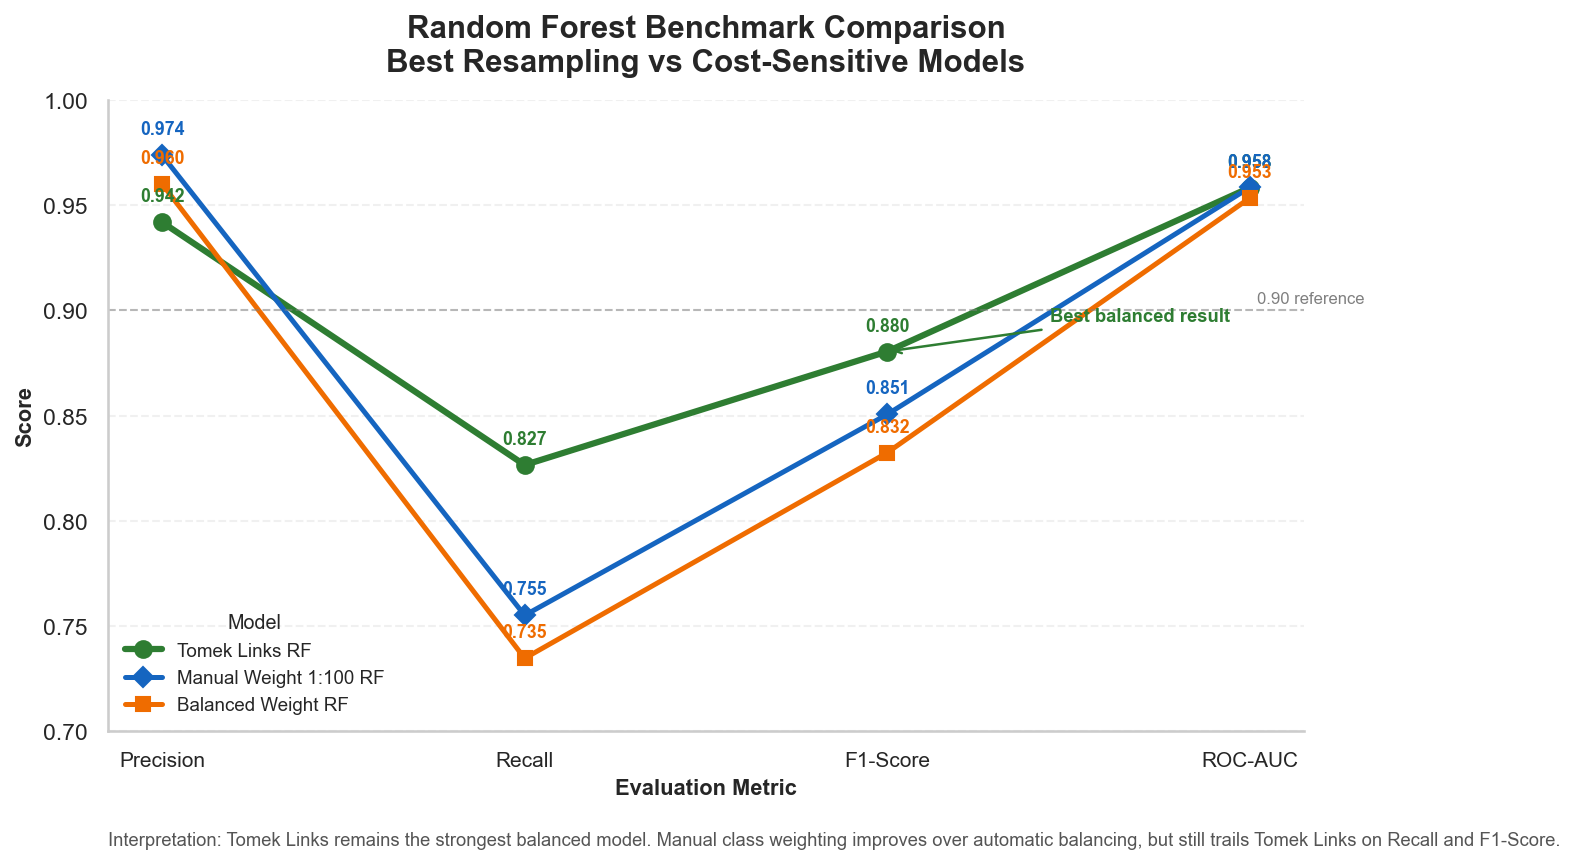

In [26]:
# ------------------------------------------------------------
# Benchmark chart: Best resampling RF vs class-weighted RF models
# ------------------------------------------------------------

# Select the three models we want to compare
benchmark_rows = pd.concat([
    rf_results_table[rf_results_table["Model"] == "Random Forest — Tomek Links"],
    rf_weighted_results_table[rf_weighted_results_table["Model"] == "Random Forest — Balanced Class Weight"],
    rf_weighted_results_table[rf_weighted_results_table["Model"] == "Random Forest — Manual Class Weight 1:100"]
], ignore_index=True)

# Clean model names for display
benchmark_rows["Model"] = benchmark_rows["Model"].replace({
    "Random Forest — Tomek Links": "Tomek Links RF",
    "Random Forest — Balanced Class Weight": "Balanced Weight RF",
    "Random Forest — Manual Class Weight 1:100": "Manual Weight 1:100 RF"
})

# Metric order for the chart
metric_order = ["Precision", "Recall", "F1-Score", "ROC-AUC"]

# Convert to long format
benchmark_long = benchmark_rows.melt(
    id_vars="Model",
    value_vars=metric_order,
    var_name="Metric",
    value_name="Score"
)

# Keep model order
model_order = [
    "Tomek Links RF",
    "Manual Weight 1:100 RF",
    "Balanced Weight RF"
]

benchmark_long["Model"] = pd.Categorical(
    benchmark_long["Model"],
    categories=model_order,
    ordered=True
)

benchmark_long["Metric"] = pd.Categorical(
    benchmark_long["Metric"],
    categories=metric_order,
    ordered=True
)

benchmark_long = benchmark_long.sort_values(["Model", "Metric"])

# Create figure
fig, ax = plt.subplots(figsize=(10.5, 6), dpi=150)

# Model styling
style_map = {
    "Tomek Links RF": {
        "color": "#2E7D32",
        "marker": "o",
        "linewidth": 3.0,
        "markersize": 8
    },
    "Manual Weight 1:100 RF": {
        "color": "#1565C0",
        "marker": "D",
        "linewidth": 2.4,
        "markersize": 7
    },
    "Balanced Weight RF": {
        "color": "#EF6C00",
        "marker": "s",
        "linewidth": 2.4,
        "markersize": 7
    }
}

# X positions
x = np.arange(len(metric_order))

# Plot one line per model
for model_name in model_order:
    model_data = benchmark_long[benchmark_long["Model"] == model_name]
    y = model_data["Score"].values
    style = style_map[model_name]
    
    ax.plot(
        x,
        y,
        label=model_name,
        color=style["color"],
        marker=style["marker"],
        linewidth=style["linewidth"],
        markersize=style["markersize"]
    )
    
    # Add value labels at each point
    for xi, yi in zip(x, y):
        ax.text(
            xi,
            yi + 0.008,
            f"{yi:.3f}",
            ha="center",
            va="bottom",
            fontsize=8.5,
            color=style["color"],
            fontweight="bold"
        )

# Chart formatting
ax.set_title(
    "Random Forest Benchmark Comparison\nBest Resampling vs Cost-Sensitive Models",
    fontsize=15,
    fontweight="bold",
    pad=14
)

ax.set_xlabel("Evaluation Metric", fontsize=10.5, fontweight="bold")
ax.set_ylabel("Score", fontsize=10.5, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(metric_order, fontsize=10)

# Zoom into the useful range so differences are visible
ax.set_ylim(0.70, 1.00)

# Grid
ax.grid(axis="y", linestyle="--", alpha=0.28)
ax.grid(axis="x", visible=False)

# Reference line
ax.axhline(0.90, linestyle="--", linewidth=1, color="gray", alpha=0.5)
ax.text(
    3.02,
    0.902,
    "0.90 reference",
    fontsize=8,
    color="gray",
    va="bottom"
)

# Highlight the main takeaway
ax.annotate(
    "Best balanced result",
    xy=(2, benchmark_rows.loc[benchmark_rows["Model"] == "Tomek Links RF", "F1-Score"].values[0]),
    xytext=(2.45, 0.895),
    arrowprops=dict(arrowstyle="->", color="#2E7D32", lw=1.2),
    fontsize=8.8,
    color="#2E7D32",
    fontweight="bold"
)

# Legend
ax.legend(
    title="Model",
    loc="lower left",
    frameon=False,
    fontsize=9,
    title_fontsize=9.5
)

# Footnote
ax.text(
    0.0,
    -0.18,
    "Interpretation: Tomek Links remains the strongest balanced model. "
    "Manual class weighting improves over automatic balancing, but still trails Tomek Links on Recall and F1-Score.",
    transform=ax.transAxes,
    fontsize=8.8,
    color="#555555"
)

# Clean look
sns.despine()

plt.tight_layout()
plt.show()

---

### Benchmark Comparison — Best Resampling vs Cost-Sensitive Models

This chart compares the strongest resampling-based Random Forest model with the two cost-sensitive Random Forest models.

### Key Findings

| Model | Main Interpretation |
|---|---|
| **Tomek Links RF** | Best balanced performance overall |
| **Manual Weight 1:100 RF** | Best cost-sensitive model |
| **Balanced Weight RF** | Lowest performance of the three benchmark models |

### Metric-Level Interpretation

- **Precision:** Manual Weight 1:100 RF performs best, meaning its fraud alerts are the most reliable.
- **Recall:** Tomek Links RF performs best, meaning it detects the highest share of real fraud cases.
- **F1-Score:** Tomek Links RF performs best, giving the strongest balance between fraud detection and false-alarm control.
- **ROC-AUC:** All three models are strong and quite close, but Manual Weight 1:100 RF is slightly highest.

### Practical Takeaway

The cost-sensitive approach improves fraud awareness without changing the data, and the manual class-weight setting performs better than automatic balancing.

However, the **Tomek Links Random Forest still remains the best balanced model overall**, because it achieves stronger Recall and F1-Score while maintaining high Precision.

---

---

## 16. Threshold Optimisation

### Objective

Most classification models first predict a probability.

For example, a transaction may receive:

| Transaction | Fraud Probability |
|---|---:|
| A | 0.82 |
| B | 0.43 |
| C | 0.18 |

By default, many models use a threshold of **0.50**.

This means:

```text
Fraud probability >= 0.50 → predict fraud
Fraud probability <  0.50 → predict normal

Why This Matters

- In fraud detection, the default threshold is not always the best choice.

- A lower threshold can catch more fraud cases, but it may also create more false alarms.

- A higher threshold can reduce false alarms, but it may also miss more fraud cases.

What We Will Test

**We will test thresholds from 0.10 to 0.90 in steps of 0.05.**

For each threshold, we will calculate:

| Metric        | Meaning                                |
| ------------- | -------------------------------------- |
| **Precision** | How reliable the fraud alerts are      |
| **Recall**    | How many real fraud cases are detected |
| **F1-Score**  | Balance between Precision and Recall   |


,Threshold,Precision,Recall,F1-Score
0,0.1000,0.6935,0.8776,0.7748
1,0.1500,0.8037,0.8776,0.8390
2,0.2000,0.8350,0.8776,0.8557
3,0.2500,0.8431,0.8776,0.8600
4,0.3000,0.8687,0.8776,0.8731
5,0.3500,0.9043,0.8673,0.8854
6,0.4000,0.9326,0.8469,0.8877
7,0.4500,0.9326,0.8469,0.8877
8,0.5000,0.9419,0.8265,0.8804
9,0.5500,0.9405,0.8061,0.8681


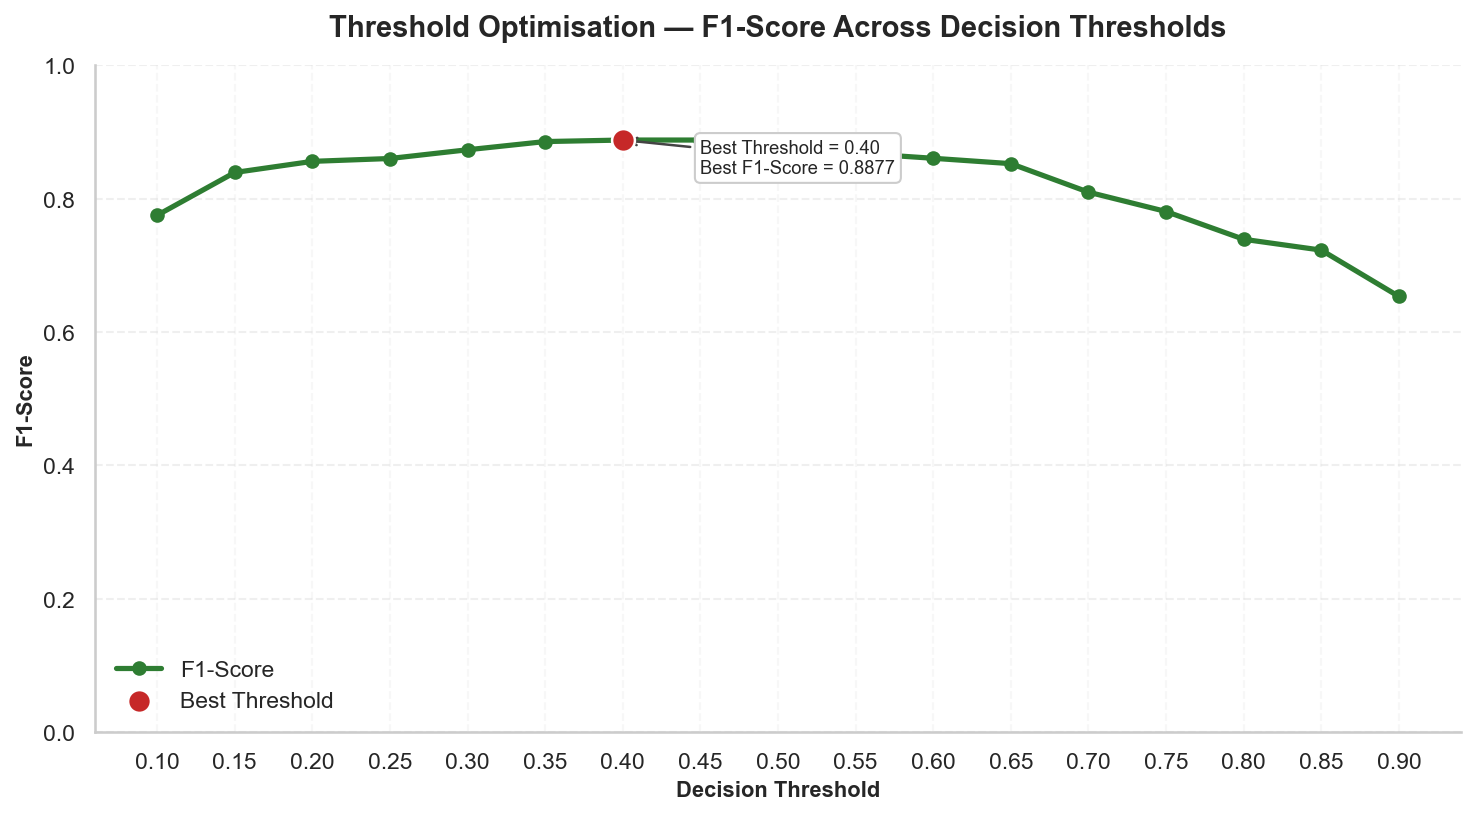

Optimal threshold based on F1-Score: 0.40
Best F1-Score: 0.8877


In [27]:
# ------------------------------------------------------------
# Threshold optimisation: F1-Score across thresholds
# Model used: Tomek Links Random Forest
# ------------------------------------------------------------

from sklearn.metrics import precision_score, recall_score, f1_score

# Select the current best balanced Random Forest model
best_rf_model = rf_models["Tomek Links"]

# Predict fraud probabilities on the unchanged test set
y_proba_tomek = best_rf_model.predict_proba(X_test_scaled)[:, 1]

# Define thresholds from 0.10 to 0.90 with step 0.05
thresholds = np.arange(0.10, 0.91, 0.05)

# Store results
threshold_results = []

# Evaluate model performance at each threshold
for threshold in thresholds:
    
    # Convert probabilities to class predictions
    y_pred_threshold = (y_proba_tomek >= threshold).astype(int)
    
    # Calculate metrics
    precision = precision_score(y_test, y_pred_threshold, zero_division=0)
    recall = recall_score(y_test, y_pred_threshold, zero_division=0)
    f1 = f1_score(y_test, y_pred_threshold, zero_division=0)
    
    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    })

# Convert to DataFrame
threshold_results_df = pd.DataFrame(threshold_results)

# Find best threshold based on highest F1-Score
best_idx = threshold_results_df["F1-Score"].idxmax()
best_threshold = threshold_results_df.loc[best_idx, "Threshold"]
best_f1 = threshold_results_df.loc[best_idx, "F1-Score"]

# Display threshold results table
display(threshold_results_df.round(4))

# ------------------------------------------------------------
# Professional F1-Score chart
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 5.6), dpi=150)

# Plot F1-Score line
ax.plot(
    threshold_results_df["Threshold"],
    threshold_results_df["F1-Score"],
    marker="o",
    linewidth=2.5,
    markersize=6,
    color="#2E7D32",
    label="F1-Score"
)

# Highlight best threshold
ax.scatter(
    best_threshold,
    best_f1,
    s=120,
    color="#C62828",
    edgecolor="white",
    linewidth=1.2,
    zorder=5,
    label="Best Threshold"
)

# Annotate best point
ax.annotate(
    f"Best Threshold = {best_threshold:.2f}\nBest F1-Score = {best_f1:.4f}",
    xy=(best_threshold, best_f1),
    xytext=(best_threshold + 0.05, best_f1 - 0.05),
    arrowprops=dict(arrowstyle="->", lw=1.2, color="#444444"),
    fontsize=8.8,
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="#CCCCCC")
)

# Chart formatting
ax.set_title(
    "Threshold Optimisation — F1-Score Across Decision Thresholds",
    fontsize=14,
    fontweight="bold",
    pad=14
)

ax.set_xlabel("Decision Threshold", fontsize=10.5, fontweight="bold")
ax.set_ylabel("F1-Score", fontsize=10.5, fontweight="bold")

ax.set_xticks(thresholds)
ax.set_ylim(0, 1.0)

ax.grid(axis="y", linestyle="--", alpha=0.30)
ax.grid(axis="x", linestyle="--", alpha=0.15)

ax.legend(frameon=False, loc="lower left")

sns.despine()
plt.tight_layout()
plt.show()

print(f"Optimal threshold based on F1-Score: {best_threshold:.2f}")
print(f"Best F1-Score: {best_f1:.4f}")

---

### Threshold Optimisation — Result Summary

The best F1-Score was achieved at a decision threshold of **0.40**.

| Setting | F1-Score |
|---|---:|
| Default threshold `0.50` | 0.8804 |
| Optimised threshold `0.40` | 0.8877 |

### Interpretation

The default threshold of `0.50` was not the best decision rule for this fraud model.

By lowering the threshold to `0.40`, the model becomes slightly more willing to classify transactions as fraud.  
This improves the F1-Score, meaning the balance between Precision and Recall becomes better.

### Practical Meaning

In fraud detection, threshold tuning is important because the model’s probability output must be converted into a business decision.

A lower threshold may catch more fraud cases, but it can also increase false alarms.  
A higher threshold may reduce false alarms, but it can miss more fraud.

For the Tomek Links Random Forest model, **0.40 is currently the best threshold based on F1-Score**.

---

In [28]:
# ------------------------------------------------------------
# Compare default threshold vs optimised threshold
# ------------------------------------------------------------

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Define thresholds to compare
threshold_comparison = {
    "Default Threshold 0.50": 0.50,
    "Optimised Threshold 0.40": best_threshold
}

# Store comparison results
threshold_comparison_results = []

for label, threshold in threshold_comparison.items():
    
    # Convert probabilities into class predictions using the selected threshold
    y_pred_threshold = (y_proba_tomek >= threshold).astype(int)
    
    # Calculate confusion matrix values
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_threshold).ravel()
    
    # Store metrics
    threshold_comparison_results.append({
        "Threshold Setting": label,
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_test, y_pred_threshold),
        "Precision": precision_score(y_test, y_pred_threshold, zero_division=0),
        "Recall": recall_score(y_test, y_pred_threshold, zero_division=0),
        "F1-Score": f1_score(y_test, y_pred_threshold, zero_division=0),
        "False Positives": fp,
        "False Negatives": fn,
        "True Positives": tp
    })

# Convert to DataFrame
threshold_comparison_df = pd.DataFrame(threshold_comparison_results)

# Format display version
threshold_comparison_display = threshold_comparison_df.copy()

for metric in ["Accuracy", "Precision", "Recall", "F1-Score"]:
    threshold_comparison_display[metric] = threshold_comparison_display[metric].map(lambda x: f"{x:.4f}")

threshold_comparison_display["Threshold"] = threshold_comparison_display["Threshold"].map(lambda x: f"{x:.2f}")

display(threshold_comparison_display)

,Threshold Setting,Threshold,Accuracy,Precision,Recall,F1-Score,False Positives,False Negatives,True Positives
0,Default Threshold 0.50,0.50,0.9996,0.9318,0.8367,0.8817,6,16,82
1,Optimised Threshold 0.40,0.40,0.9996,0.9326,0.8469,0.8877,6,15,83


---

### Default vs Optimised Threshold — Result Summary

The optimised threshold slightly improved the Tomek Links Random Forest model.

| Threshold | Precision | Recall | F1-Score | False Positives | False Negatives | True Positives |
|---:|---:|---:|---:|---:|---:|---:|
| `0.50` | 0.9318 | 0.8367 | 0.8817 | 6 | 16 | 82 |
| `0.40` | 0.9326 | 0.8469 | 0.8877 | 6 | 15 | 83 |

### Interpretation

The default threshold of `0.50` was already strong.

However, the optimised threshold of `0.40` performs slightly better.  
It detects **83 fraud cases** instead of **82**, while keeping false positives unchanged at **6**.

### Practical Meaning

This is a useful improvement because the model catches one additional fraud case without increasing the number of normal transactions wrongly flagged as fraud.

For this model, the optimised threshold of **0.40** gives the best F1-Score and is currently the preferred decision threshold.

---

---

## 17. SMOTE + XGBoost + `scale_pos_weight`

### Objective

We now test an advanced imbalance-handling approach using **XGBoost**.

XGBoost is a powerful tree-based boosting model that often performs well on structured/tabular datasets.

### Simple Explanation

Random Forest builds many trees independently and combines their votes.

XGBoost builds trees step by step.  
Each new tree focuses on correcting mistakes made by the previous trees.

This can make XGBoost very strong for fraud detection.

### Why `scale_pos_weight` Matters

Fraud cases are rare, so XGBoost needs to know that the fraud class is more important.

`scale_pos_weight` tells XGBoost to give more importance to the positive class:

```text
Positive class = Fraud = Class 1

In this experiment, we use

| Component            | Purpose                                     |
| -------------------- | ------------------------------------------- |
| **SMOTE**            | Creates synthetic fraud-like examples       |
| **XGBoost**          | Trains a strong boosting model              |
| **scale_pos_weight** | Adds extra cost sensitivity for fraud cases |


In [29]:
# ------------------------------------------------------------
# XGBoost setup check
# ------------------------------------------------------------

# XGBoost is needed for the final expert model:
# SMOTE + XGBoost + scale_pos_weight

try:
    from xgboost import XGBClassifier
    print("XGBoost is already installed and imported successfully.")

except ModuleNotFoundError:
    print("XGBoost is not installed. Installing now...")
    %pip install -q xgboost
    
    from xgboost import XGBClassifier
    print("XGBoost installed and imported successfully.")

XGBoost is already installed and imported successfully.


---

### Understanding `scale_pos_weight`

`scale_pos_weight` is an XGBoost parameter used for imbalanced classification.

It tells XGBoost how much more importance should be given to the positive class.

In this project:

```text
Positive class = Fraud transaction = Class 1
Negative class = Normal transaction = Class 0

In [30]:
# ------------------------------------------------------------
# Calculate scale_pos_weight values
# ------------------------------------------------------------

# Original training class counts
negative_count_original = (y_train == 0).sum()
positive_count_original = (y_train == 1).sum()

# Standard imbalance ratio from original training data
scale_pos_weight_original = negative_count_original / positive_count_original

# SMOTE training class counts
negative_count_smote = (y_train_smote == 0).sum()
positive_count_smote = (y_train_smote == 1).sum()

# Ratio after SMOTE
scale_pos_weight_smote = negative_count_smote / positive_count_smote

# Create summary table
scale_pos_weight_summary = pd.DataFrame({
    "Training Data": ["Original Training Data", "SMOTE Training Data"],
    "Normal Count": [negative_count_original, negative_count_smote],
    "Fraud Count": [positive_count_original, positive_count_smote],
    "scale_pos_weight": [scale_pos_weight_original, scale_pos_weight_smote]
})

# Format display version
scale_pos_weight_summary_display = scale_pos_weight_summary.copy()
scale_pos_weight_summary_display["Normal Count"] = scale_pos_weight_summary_display["Normal Count"].map("{:,}".format)
scale_pos_weight_summary_display["Fraud Count"] = scale_pos_weight_summary_display["Fraud Count"].map("{:,}".format)
scale_pos_weight_summary_display["scale_pos_weight"] = scale_pos_weight_summary_display["scale_pos_weight"].map("{:.2f}".format)

display(scale_pos_weight_summary_display)

,Training Data,Normal Count,Fraud Count,scale_pos_weight
0,Original Training Data,"227,451",394,577.29
1,SMOTE Training Data,"227,451","227,451",1.00


---

### `scale_pos_weight` Result Summary

`scale_pos_weight` is an XGBoost parameter used for imbalanced classification. It tells the model how much more attention should be given to the positive class.

In this project:

| Class | Meaning |
|---:|---|
| `0` | Normal transaction |
| `1` | Fraud transaction |

The formula is:

```text
scale_pos_weight = number of normal transactions / number of fraud transactions

Before SMOTE, the original training data contains:

| Class               |   Count |
| ------------------- | ------: |
| Normal transactions | 227,451 |
| Fraud transactions  |     394 |

scale_pos_weight = 227,451 / 394 = 577.29

This means there are about 577 normal transactions for every 1 fraud transaction.

After SMOTE, the training data is balanced:

| Class               |   Count |
| ------------------- | ------: |
| Normal transactions | 227,451 |
| Fraud transactions  | 227,451 |

scale_pos_weight = 227,451 / 227,451 = 1.00


In [31]:
# ------------------------------------------------------------
# Train SMOTE + XGBoost model
# ------------------------------------------------------------

# We train XGBoost on the SMOTE-balanced training data:
# X_train_smote, y_train_smote
#
# Why?
# SMOTE has already created a balanced training set:
# 50% normal transactions and 50% fraud transactions.
#
# Therefore, scale_pos_weight is set to 1.0.
# This means XGBoost treats both classes equally after SMOTE balancing.

xgb_smote_model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.10,
    subsample=0.80,
    colsample_bytree=0.80,
    scale_pos_weight=scale_pos_weight_smote,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

# Train the model on SMOTE-balanced training data
xgb_smote_model.fit(X_train_smote, y_train_smote)

print("SMOTE + XGBoost model trained successfully.")
print(f"scale_pos_weight used: {scale_pos_weight_smote:.2f}")

SMOTE + XGBoost model trained successfully.
scale_pos_weight used: 1.00


In [32]:
# ------------------------------------------------------------
# Evaluate SMOTE + XGBoost model
# ------------------------------------------------------------

xgb_smote_results_table = evaluate_model(
    model=xgb_smote_model,
    X_test=X_test_scaled,
    y_test=y_test,
    model_name="SMOTE + XGBoost"
)

# Format display version
xgb_smote_results_display = xgb_smote_results_table.copy()

for metric in ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]:
    xgb_smote_results_display[metric] = xgb_smote_results_display[metric].map(lambda x: f"{x:.4f}")

display(xgb_smote_results_display)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,SMOTE + XGBoost,0.9919,0.1601,0.8776,0.2709,0.9813


---

### SMOTE + XGBoost — Result Summary

The SMOTE + XGBoost model achieved the highest ROC-AUC so far.

| Metric | Score | Meaning |
|---|---:|---|
| Precision | 0.1601 | Many fraud alerts are false alarms |
| Recall | 0.8776 | Most fraud cases are detected |
| F1-Score | 0.2709 | Poor balance between Precision and Recall |
| ROC-AUC | 0.9813 | Strong separation ability overall |

### Interpretation

SMOTE + XGBoost is very strong at ranking fraud transactions higher than normal transactions.

This explains the high ROC-AUC.

However, at the default threshold, the model produces too many false positives.  
This causes Precision to drop sharply.

### Practical Meaning

For real-time fraud detection, this model is aggressive.

It catches many fraud cases, but it may also flag too many normal customers.

Therefore, SMOTE + XGBoost is not the best final model at the default threshold.

It may become more useful after threshold tuning, but based on the current result, the threshold-optimised Tomek Links Random Forest remains the stronger practical option.

---

In [33]:
# ------------------------------------------------------------
# Final comparison: best Random Forest vs SMOTE + XGBoost
# ------------------------------------------------------------

# Create final comparison table from existing results
final_model_comparison = pd.DataFrame({
    "Model": [
        "Tomek Links RF — Default Threshold 0.50",
        "Tomek Links RF — Optimised Threshold 0.40",
        "SMOTE + XGBoost — Default Threshold 0.50"
    ],
    "Accuracy": [
        threshold_comparison_df.loc[0, "Accuracy"],
        threshold_comparison_df.loc[1, "Accuracy"],
        xgb_smote_results_table.loc[0, "Accuracy"]
    ],
    "Precision": [
        threshold_comparison_df.loc[0, "Precision"],
        threshold_comparison_df.loc[1, "Precision"],
        xgb_smote_results_table.loc[0, "Precision"]
    ],
    "Recall": [
        threshold_comparison_df.loc[0, "Recall"],
        threshold_comparison_df.loc[1, "Recall"],
        xgb_smote_results_table.loc[0, "Recall"]
    ],
    "F1-Score": [
        threshold_comparison_df.loc[0, "F1-Score"],
        threshold_comparison_df.loc[1, "F1-Score"],
        xgb_smote_results_table.loc[0, "F1-Score"]
    ],
    "ROC-AUC": [
        rf_results_table.loc[
            rf_results_table["Model"] == "Random Forest — Tomek Links",
            "ROC-AUC"
        ].values[0],
        rf_results_table.loc[
            rf_results_table["Model"] == "Random Forest — Tomek Links",
            "ROC-AUC"
        ].values[0],
        xgb_smote_results_table.loc[0, "ROC-AUC"]
    ],
    "Business Interpretation": [
        "Strong balanced model at default threshold",
        "Best practical model so far; catches one extra fraud case with no extra false positives",
        "Very high ROC-AUC and Recall, but too many false alarms"
    ]
})

# Format display version
final_model_comparison_display = final_model_comparison.copy()

for metric in ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]:
    final_model_comparison_display[metric] = final_model_comparison_display[metric].map(lambda x: f"{x:.4f}")

display(final_model_comparison_display)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Business Interpretation
0,Tomek Links RF — Default Threshold 0.50,0.9996,0.9318,0.8367,0.8817,0.9583,Strong balanced model at default threshold
1,Tomek Links RF — Optimised Threshold 0.40,0.9996,0.9326,0.8469,0.8877,0.9583,Best practical model so far; catches one extra...
2,SMOTE + XGBoost — Default Threshold 0.50,0.9919,0.1601,0.8776,0.2709,0.9813,"Very high ROC-AUC and Recall, but too many fal..."


---

### Final Model Comparison — Result Summary

The final comparison shows a clear trade-off between statistical separation and practical usability.

| Model | Main Result |
|---|---|
| **Tomek Links RF — Default Threshold 0.50** | Strong balanced model |
| **Tomek Links RF — Optimised Threshold 0.40** | Best practical model so far |
| **SMOTE + XGBoost — Default Threshold 0.50** | Highest ROC-AUC, but too many false alarms |

### Interpretation

SMOTE + XGBoost achieved the highest ROC-AUC and Recall.

This means it is good at ranking fraud transactions higher than normal transactions and catches many fraud cases.

However, its Precision is very low.  
This means many transactions predicted as fraud are actually normal.

For real-time fraud detection, this can create too many false alerts and may disturb normal customers or overload fraud-review teams.

### Practical Recommendation

The **Tomek Links Random Forest with threshold 0.40** is currently the strongest practical model.

It gives:

- high Precision,
- strong Recall,
- the best F1-Score,
- and only a small number of false positives.

This makes it more suitable for real-time fraud detection than the default SMOTE + XGBoost model.

---

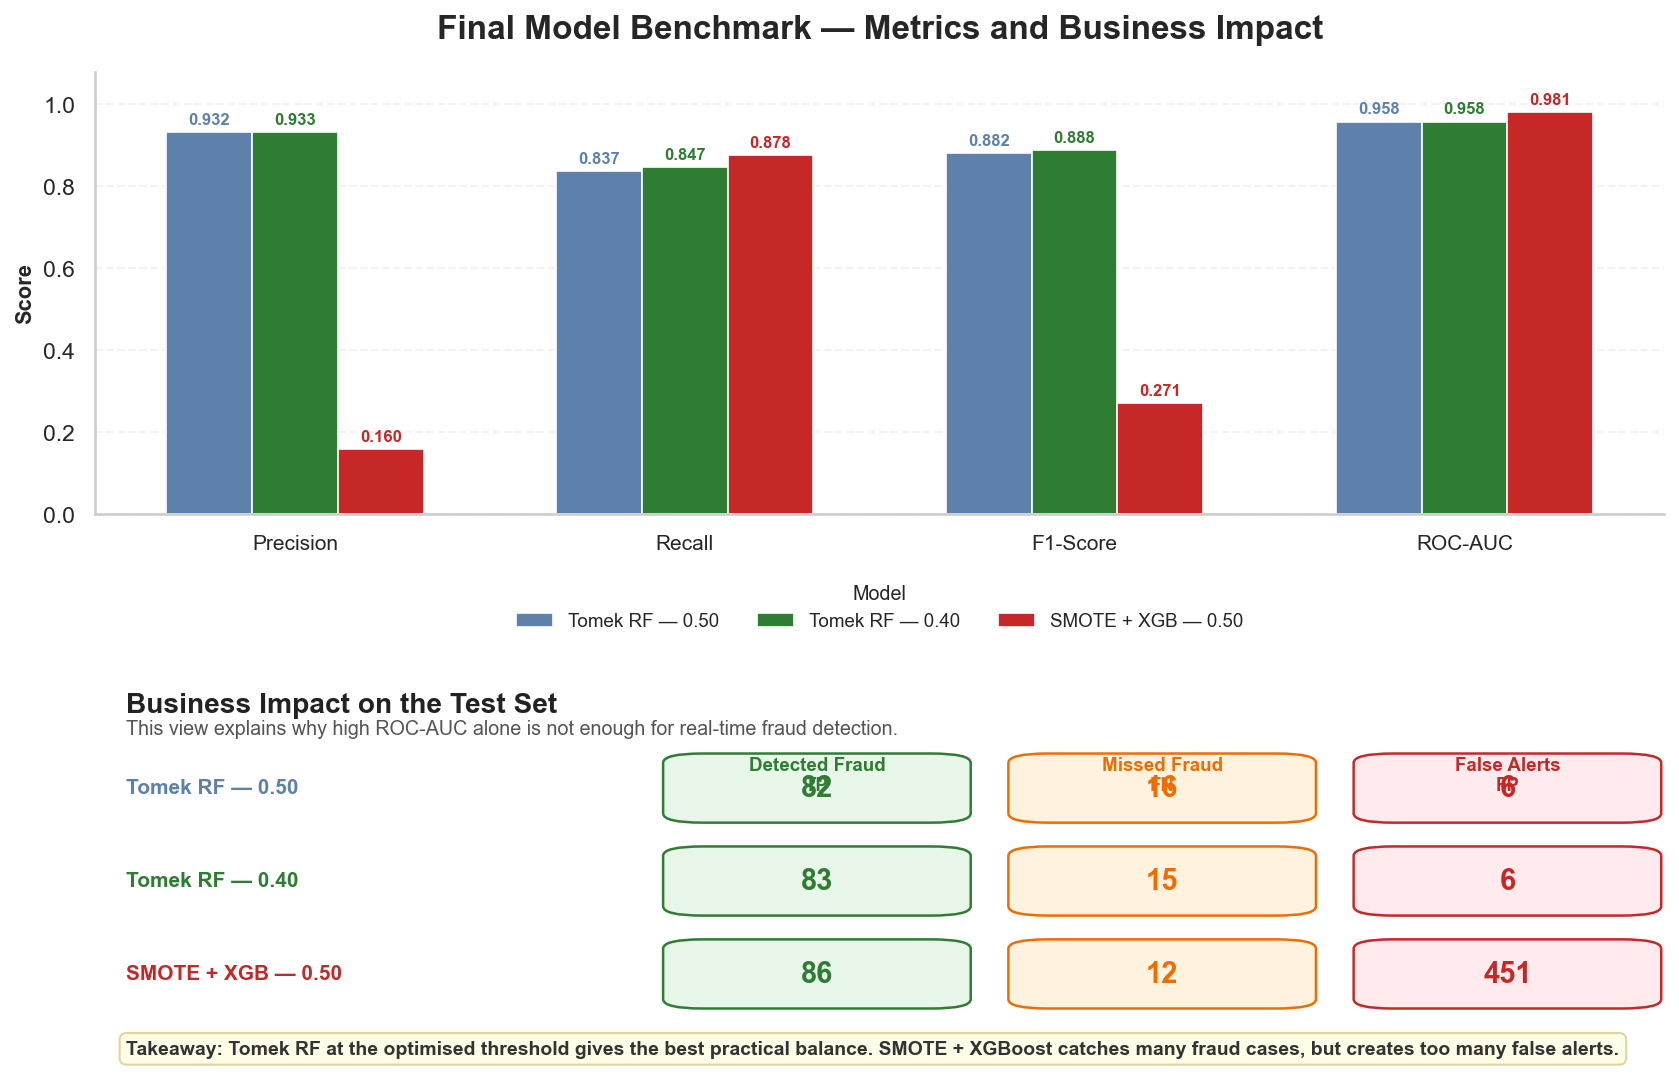

In [36]:
# ------------------------------------------------------------
# Final benchmark dashboard: corrected and cleaner version
# ------------------------------------------------------------

from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import matplotlib.patches as patches

# ------------------------------------------------------------
# Prepare final model predictions
# ------------------------------------------------------------

final_models_for_dashboard = {
    "Tomek RF — 0.50": {
        "proba": y_proba_tomek,
        "threshold": 0.50
    },
    "Tomek RF — 0.40": {
        "proba": y_proba_tomek,
        "threshold": best_threshold   # Use exact optimised threshold
    },
    "SMOTE + XGB — 0.50": {
        "proba": xgb_smote_model.predict_proba(X_test_scaled)[:, 1],
        "threshold": 0.50
    }
}

dashboard_rows = []

for model_name, config in final_models_for_dashboard.items():
    
    y_pred = (config["proba"] >= config["threshold"]).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    
    dashboard_rows.append({
        "Model": model_name,
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1-Score": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, config["proba"]),
        "Detected Fraud": tp,
        "Missed Fraud": fn,
        "False Alerts": fp
    })

dashboard_df = pd.DataFrame(dashboard_rows)

# ------------------------------------------------------------
# Create dashboard
# ------------------------------------------------------------

fig = plt.figure(figsize=(13.5, 8.6), dpi=150)

gs = fig.add_gridspec(
    nrows=2,
    ncols=1,
    height_ratios=[1.25, 1.05],
    hspace=0.44
)

ax_metrics = fig.add_subplot(gs[0])
ax_business = fig.add_subplot(gs[1])

# ------------------------------------------------------------
# Panel 1: grouped metric bar chart
# ------------------------------------------------------------

metrics = ["Precision", "Recall", "F1-Score", "ROC-AUC"]
x = np.arange(len(metrics))
bar_width = 0.22

model_colors = {
    "Tomek RF — 0.50": "#5E81AC",
    "Tomek RF — 0.40": "#2E7D32",
    "SMOTE + XGB — 0.50": "#C62828"
}

offsets = [-bar_width, 0, bar_width]

for offset, model_name in zip(offsets, dashboard_df["Model"]):
    
    model_scores = dashboard_df.loc[
        dashboard_df["Model"] == model_name,
        metrics
    ].values.flatten()
    
    bars = ax_metrics.bar(
        x + offset,
        model_scores,
        width=bar_width,
        label=model_name,
        color=model_colors[model_name],
        edgecolor="white",
        linewidth=0.8
    )
    
    for bar, score in zip(bars, model_scores):
        ax_metrics.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.012,
            f"{score:.3f}",
            ha="center",
            va="bottom",
            fontsize=8,
            fontweight="bold",
            color=model_colors[model_name]
        )

ax_metrics.set_title(
    "Final Model Benchmark — Metrics and Business Impact",
    fontsize=16,
    fontweight="bold",
    pad=16
)

ax_metrics.set_ylabel("Score", fontsize=10.5, fontweight="bold")
ax_metrics.set_xticks(x)
ax_metrics.set_xticklabels(metrics, fontsize=10)
ax_metrics.set_ylim(0, 1.08)

ax_metrics.grid(axis="y", linestyle="--", alpha=0.25)
ax_metrics.grid(axis="x", visible=False)

# Move legend outside the plot area
ax_metrics.legend(
    title="Model",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=3,
    frameon=False,
    fontsize=9,
    title_fontsize=9.5
)

sns.despine(ax=ax_metrics)

# ------------------------------------------------------------
# Panel 2: business impact cards
# ------------------------------------------------------------

ax_business.set_xlim(0, 1)
ax_business.set_ylim(0, 1)
ax_business.axis("off")

ax_business.text(
    0.02,
    0.95,
    "Business Impact on the Test Set",
    fontsize=13.5,
    fontweight="bold",
    color="#222222"
)

ax_business.text(
    0.02,
    0.89,
    "This view explains why high ROC-AUC alone is not enough for real-time fraud detection.",
    fontsize=9.5,
    color="#555555"
)

# Layout
model_x = 0.02
card_x_positions = [0.38, 0.60, 0.82]
row_y_positions = [0.67, 0.42, 0.17]

card_w = 0.16
card_h = 0.15

headers = [
    ("Detected Fraud\nTP", "#2E7D32"),
    ("Missed Fraud\nFN", "#EF6C00"),
    ("False Alerts\nFP", "#C62828")
]

for x_pos, (header, color) in zip(card_x_positions, headers):
    ax_business.text(
        x_pos + card_w / 2,
        0.78,
        header,
        ha="center",
        va="center",
        fontsize=9,
        fontweight="bold",
        color=color
    )

card_specs = {
    "Detected Fraud": {"face": "#E8F5E9", "edge": "#2E7D32"},
    "Missed Fraud": {"face": "#FFF3E0", "edge": "#EF6C00"},
    "False Alerts": {"face": "#FFEBEE", "edge": "#C62828"}
}

for row_idx, (_, row) in enumerate(dashboard_df.iterrows()):
    
    y_pos = row_y_positions[row_idx]
    
    ax_business.text(
        model_x,
        y_pos + card_h / 2,
        row["Model"],
        ha="left",
        va="center",
        fontsize=10,
        fontweight="bold",
        color=model_colors[row["Model"]]
    )
    
    for x_pos, col_name in zip(card_x_positions, ["Detected Fraud", "Missed Fraud", "False Alerts"]):
        
        spec = card_specs[col_name]
        
        rect = patches.FancyBboxPatch(
            (x_pos, y_pos),
            card_w,
            card_h,
            boxstyle="round,pad=0.018,rounding_size=0.025",
            facecolor=spec["face"],
            edgecolor=spec["edge"],
            linewidth=1.2
        )
        ax_business.add_patch(rect)
        
        ax_business.text(
            x_pos + card_w / 2,
            y_pos + card_h / 2,
            f"{int(row[col_name]):,}",
            ha="center",
            va="center",
            fontsize=14,
            fontweight="bold",
            color=spec["edge"]
        )

ax_business.text(
    0.02,
    0.03,
    "Takeaway: Tomek RF at the optimised threshold gives the best practical balance. "
    "SMOTE + XGBoost catches many fraud cases, but creates too many false alerts.",
    fontsize=9.3,
    fontweight="bold",
    color="#333333",
    bbox=dict(
        boxstyle="round,pad=0.35",
        facecolor="#FFFDE7",
        edgecolor="#DDD6A0"
    )
)

plt.show()